In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Начнем с EDA (Exploratory data analysis)

В датасете представлены следующие столбцы:

- ApplicationDate: Дата подачи заявки на кредит
- Age: Возраст заявителя
- AnnualIncome: Годовой доход
- CreditScore: Оценка кредитоспособности
- LoanAmount: Запрашиваемая сумма кредита
- LoanDuration: Срок погашения кредита
- MaritalStatus: Семейное положение заявителя
- NumberOfDependents: Количество иждивенцев
- HomeOwnershipStatus: Статус владения жильем
- MonthlyDebtPayments: Ежемесячные обязательства по долгам
- CreditCardUtilizationRate: Процент использования кредитной карты
- NumberOfOpenCreditLines: Активные кредитные линии
- NumberOfCreditInquiries: Количество запросов на кредит
- DebtToIncomeRatio: Соотношение долга к доходу
- BankruptcyHistory: История банкротств
- LoanPurpose: Цель кредита
- PreviousLoanDefaults: Предыдущие дефолты по кредитам
- PaymentHistory: История платежей
- LengthOfCreditHistory: Длительность кредитной истории
- SavingsAccountBalance: Баланс сберегательного счета
- CheckingAccountBalance: Баланс расчетного счета
- TotalAssets: Общая стоимость активов
- TotalLiabilities: Общая сумма обязательств
- MonthlyIncome: Ежемесячный доход
- UtilityBillsPaymentHistory: История платежей по коммунальным услугам
- JobTenure: Длительность работы на текущем месте
- EmploymentStatus: Статус занятости
- EducationLevel: Уровень образования
- Experience: Опыт работы
- NetWorth: Чистая стоимость активов
- BaseInterestRate: Базовая процентная ставка
- InterestRate: Применяемая процентная ставка
- MonthlyLoanPayment: Ежемесячный платеж по кредиту
- TotalDebtToIncomeRatio: Общее соотношение долга к доходу
- LoanApproved: Статус одобрения кредита
- RiskScore: Оценка риска

In [66]:
train = pd.read_csv("data/train.csv")
test =  pd.read_csv("data/test.csv")
test_ids = test["ID"].copy()

print(train.info())
print(test.info())
print(test.isna().sum().sum())
print(train.head())
print(train["RiskScore"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

## Основная информация по каждому признаку

In [65]:
print(train.describe())


                Age   AnnualIncome  CreditScore     LoanAmount  LoanDuration  \
count  10487.000000   10487.000000  9986.000000    9986.000000  10487.000000   
mean      39.850386  131587.872127   678.082716   29874.218306     53.439878   
std       11.614132  115791.941909   175.192486   27705.509722     24.493562   
min       18.000000   15000.000000   300.000000    1063.000000     12.000000   
25%       32.000000   20959.500000   550.000000   12658.000000     36.000000   
50%       40.000000   89015.000000   722.500000   21828.500000     48.000000   
75%       48.000000  257025.000000   850.000000   37158.000000     60.000000   
max       80.000000  748508.000000   850.000000  418997.000000    120.000000   

       NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
count        10487.000000          9986.000000               10487.000000   
mean             1.568323           546.458642                   0.284397   
std              1.418684           501.981888  

## Проверим наличие "пустых" none значений

In [5]:
none_values = train.isna().sum()
none_percent = (none_values / len(train)) * 100

print(none_percent)

train_without_none = train.dropna()
train_filled = train.copy()

# Заполняем пропуски
num_features = train_filled.select_dtypes(include="number").columns
train_filled[num_features] = train_filled[num_features].fillna(train_filled[num_features].mean())

categorial_features = train_filled.select_dtypes("object").columns
for col in categorial_features:
    train_filled[col] = train_filled[col].fillna(train_filled[col].mode()[0])

pre_df = train_without_none.copy()
pre_test = test.copy()



ApplicationDate               4.810747
Age                           4.810747
AnnualIncome                  4.810747
CreditScore                   9.358265
LoanAmount                    9.358265
LoanDuration                  4.810747
MaritalStatus                 4.810747
NumberOfDependents            4.810747
HomeOwnershipStatus           4.810747
MonthlyDebtPayments           9.358265
CreditCardUtilizationRate     4.810747
NumberOfOpenCreditLines       4.810747
NumberOfCreditInquiries       4.810747
DebtToIncomeRatio             4.810747
BankruptcyHistory             9.358265
LoanPurpose                   9.358265
PreviousLoanDefaults          4.810747
PaymentHistory                4.810747
LengthOfCreditHistory         4.810747
SavingsAccountBalance         4.810747
CheckingAccountBalance        9.358265
TotalAssets                   9.358265
TotalLiabilities              4.810747
MonthlyIncome                 4.810747
UtilityBillsPaymentHistory    4.810747
JobTenure                

# Попробуем изменить некоторые категориальные признаки на числовые

In [6]:
# Порядковые признаки:

# Заметим упорядоченный признак EducationLevel (минимальный риск - умные люди)
education_map = { 'Doctorate': 0, 'Master': 1, 'Bachelor': 2, 'Associate': 3, 'High School': 4}
pre_df["EducationLevel_num"] = pre_df["EducationLevel"].map(education_map)
pre_test["EducationLevel_num"] = pre_test["EducationLevel"].map(education_map)

# Также хороший вариант это EmploymentStatus (Работаешь - риск минимальный):
employment_status_map = {"Employed" : 0, "Self-Employed" : 1, "Unemployed" : 2}
pre_df["EmploymentStatus_num"] = pre_df["EmploymentStatus"].map(employment_status_map)
pre_test["EmploymentStatus_num"] = pre_test["EmploymentStatus"].map(employment_status_map)

# Начнем с логичного HomeOwnershipStatus (Если есть свое жилье - риск минимальный):

home_status_map = {"Own" : 0, "Mortgage" : 1, "Rent" : 2, "Other" : 3}
pre_df["HomeOwnershipStatus_num"] = pre_df["HomeOwnershipStatus"].map(home_status_map)
pre_test["HomeOwnershipStatus_num"] = pre_test["HomeOwnershipStatus"].map(home_status_map)

# Номинальные признаки (исп One-Hot Encoding)

pre_df = pd.get_dummies(pre_df, columns=["MaritalStatus"], prefix="Marital")
pre_test = pd.get_dummies(pre_test, columns=["MaritalStatus"], prefix="Marital")

pre_df = pd.get_dummies(pre_df, columns=["LoanPurpose"], prefix="LoanPurpose")
pre_test = pd.get_dummies(pre_test, columns=["LoanPurpose"], prefix="LoanPurpose")

bool_cols1 = pre_df.select_dtypes(include="bool").columns
bool_cols2 = pre_test.select_dtypes(include="bool").columns

pre_df[bool_cols1] = pre_df[bool_cols1].astype(int)
pre_test[bool_cols2] = pre_test[bool_cols2].astype(int)


# Можно еще что-нибудь придумать с MaritalStatus и LoanPurpose
# marital_map = { 'Married': 0, 'Single': 1, 'Divorced': 2, 'Widowed': 3 }
# pre_df["MaritalStatus_num"] = pre_df["MaritalStatus"].map(marital_map)
# pre_test["MaritalStatus_num"] = pre_test["MaritalStatus"].map(marital_map)

# loan_purpose_map = { 'Home': 0, 'Auto': 1, 'Education': 2, 'Debt Consolidation': 3, 'Other': 4 }
# pre_df['LoanPurpose_num'] = pre_df['LoanPurpose'].map(loan_purpose_map)
# pre_test['LoanPurpose_num'] = pre_test['LoanPurpose'].map(loan_purpose_map)

## Проверим на аномалии в столбцах

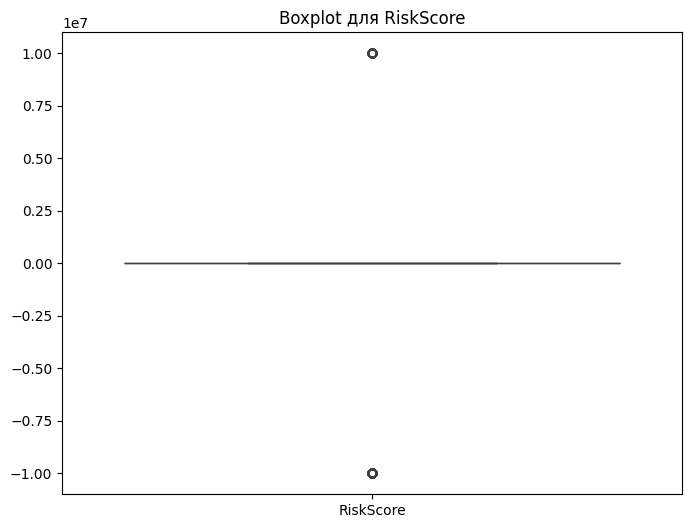

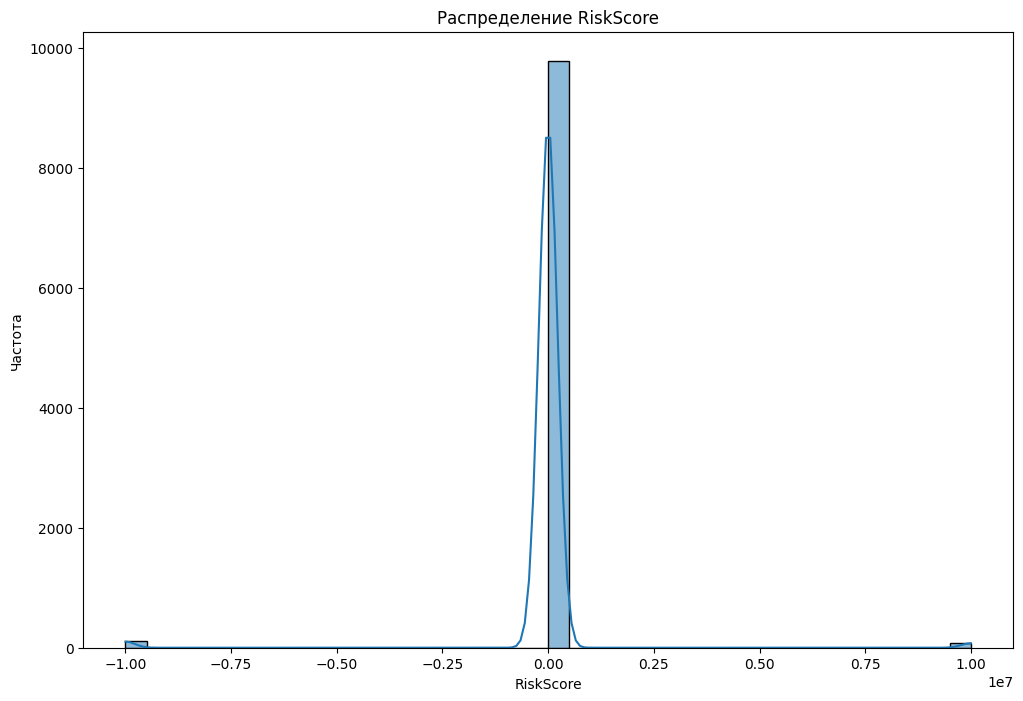

count    9.986000e+03
mean    -3.099606e+04
std      1.411392e+06
min     -9.999999e+06
25%      3.251016e+01
50%      4.406128e+01
75%      6.532677e+01
max      1.000000e+07
Name: RiskScore, dtype: float64
92.79116783385172


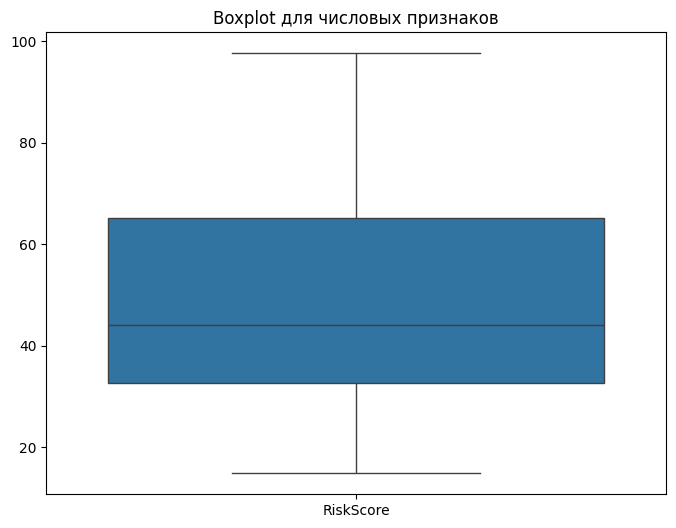

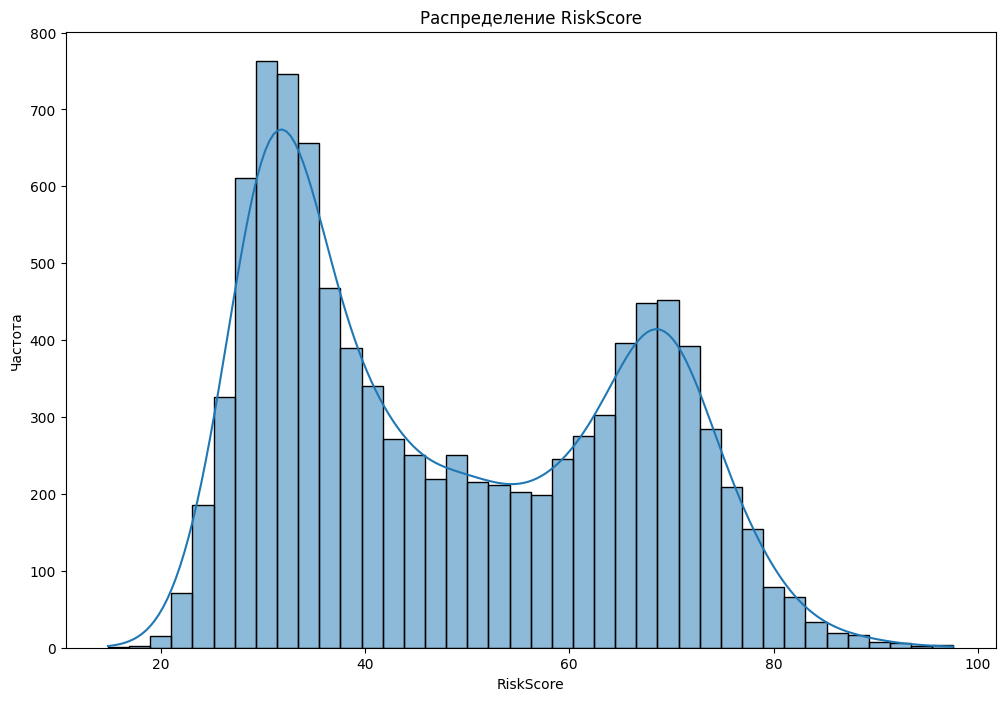

In [68]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=pre_df[['RiskScore']])
plt.title("Boxplot для RiskScore")
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(pre_df['RiskScore'], bins=40, kde=True)
plt.title("Распределение RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Частота")
plt.show()

# Есть аномалии, RiskScore не может быть отрицательным и очень большим

print(pre_df["RiskScore"].describe())
print(pre_df["RiskScore"].quantile(0.991)) # примерно можно взять 100, что больше 100 мы удаляем
df = pre_df.copy()
df_test = pre_test.copy()
df = df[(df["RiskScore"] >= 0) & (df["RiskScore"] < 100)]

# Построим новый график
plt.figure(figsize=(8, 6))

sns.boxplot(data=df[['RiskScore']])
plt.title("Boxplot для числовых признаков")
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(df['RiskScore'], bins=40, kde=True)
plt.title("Распределение RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Частота")
plt.show()




## Построим матрицу корреляций для числовых признаков 

                                     Age  AnnualIncome  CreditScore  \
Age                             1.000000      0.039471     0.056968   
AnnualIncome                    0.039471      1.000000     0.617930   
CreditScore                     0.056968      0.617930     1.000000   
LoanAmount                      0.006178      0.002974    -0.003894   
LoanDuration                    0.019498     -0.017199    -0.014434   
NumberOfDependents              0.018494     -0.004079    -0.001750   
MonthlyDebtPayments            -0.013430      0.010828     0.006162   
CreditCardUtilizationRate       0.026346     -0.009095    -0.010263   
NumberOfOpenCreditLines        -0.003938      0.003477    -0.000313   
NumberOfCreditInquiries        -0.001098      0.014758     0.006429   
DebtToIncomeRatio              -0.005035      0.009278     0.012618   
BankruptcyHistory               0.005132     -0.000043    -0.003788   
PreviousLoanDefaults           -0.007779     -0.009899    -0.011122   
Paymen

<Axes: >

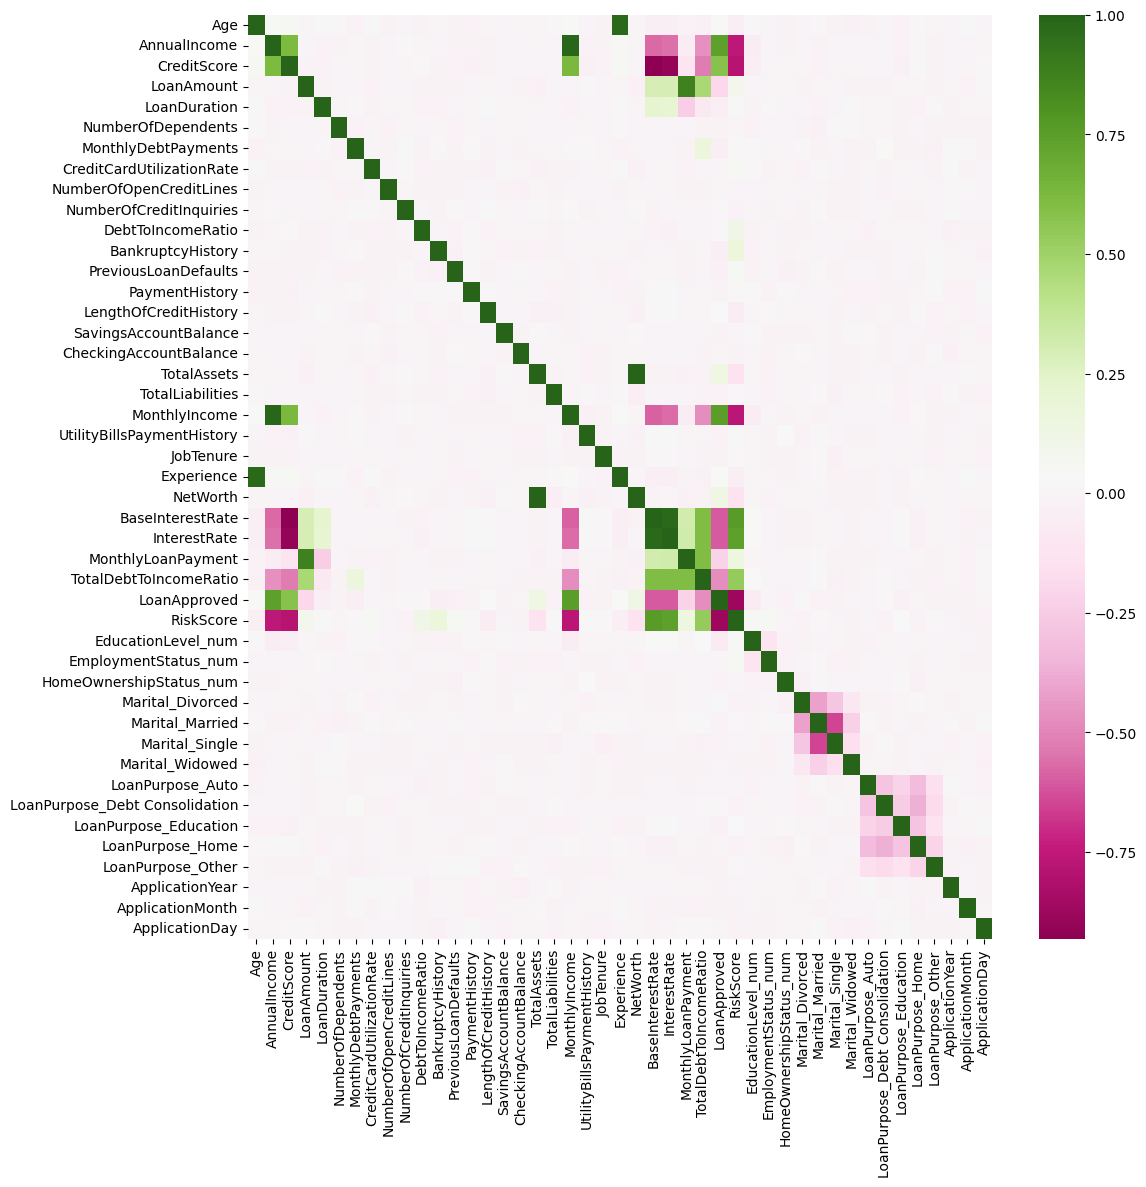

In [69]:
plt.figure(figsize=(12,12))

df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
df["ApplicationYear"] = df["ApplicationDate"].dt.year
df["ApplicationMonth"] = df["ApplicationDate"].dt.month
df["ApplicationDay"] = df["ApplicationDate"].dt.day

df_test["ApplicationDate"] = pd.to_datetime(df_test["ApplicationDate"])
df_test["ApplicationYear"] = df_test["ApplicationDate"].dt.year
df_test["ApplicationMonth"] = df_test["ApplicationDate"].dt.month
df_test["ApplicationDay"] = df_test["ApplicationDate"].dt.day

# Выбираем только числовые признаки для матрицы, категориальные нам не подходят
number_feature_count = df.select_dtypes("number").columns

print(df[number_feature_count].corr())

sns.heatmap(df[number_feature_count].corr(), cmap="PiYG")


In [9]:

only_RiskScore_top = df[number_feature_count].corr()[["RiskScore"]]
only_RiskScore_top["ABS"] = only_RiskScore_top["RiskScore"].abs()

# Топ 10 самых связанных в DF с заполненными значениями
print(only_RiskScore_top.sort_values(by="ABS", ascending=False).head(10))



                        RiskScore       ABS
RiskScore                1.000000  1.000000
LoanApproved            -0.872722  0.872722
CreditScore             -0.785425  0.785425
MonthlyIncome           -0.770608  0.770608
BaseInterestRate         0.758712  0.758712
AnnualIncome            -0.758480  0.758480
InterestRate             0.742940  0.742940
TotalDebtToIncomeRatio   0.532384  0.532384
BankruptcyHistory        0.177559  0.177559
MonthlyLoanPayment       0.151459  0.151459



## Попробуем построить другие графики

count    9787.000000
mean        0.512108
std         0.499879
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: LoanApproved, dtype: float64
count    9787.000000
mean      677.911515
std       175.374136
min       300.000000
25%       550.000000
50%       722.000000
75%       850.000000
max       850.000000
Name: CreditScore, dtype: float64
count     9787.000000
mean     10831.569727
std       9398.941396
min       1250.000000
25%       1666.750000
50%       7339.916667
75%      21384.000000
max      25000.000000
Name: MonthlyIncome, dtype: float64
count    9787.000000
mean        0.200502
std         0.094560
min         0.052494
25%         0.119862
50%         0.182072
75%         0.265098
max         0.722497
Name: BaseInterestRate, dtype: float64
count      9787.000000
mean     131527.784510
std      116069.069481
min       15000.000000
25%       20699.500000
50%       88615.000000
75%      257780.500000
max      748508

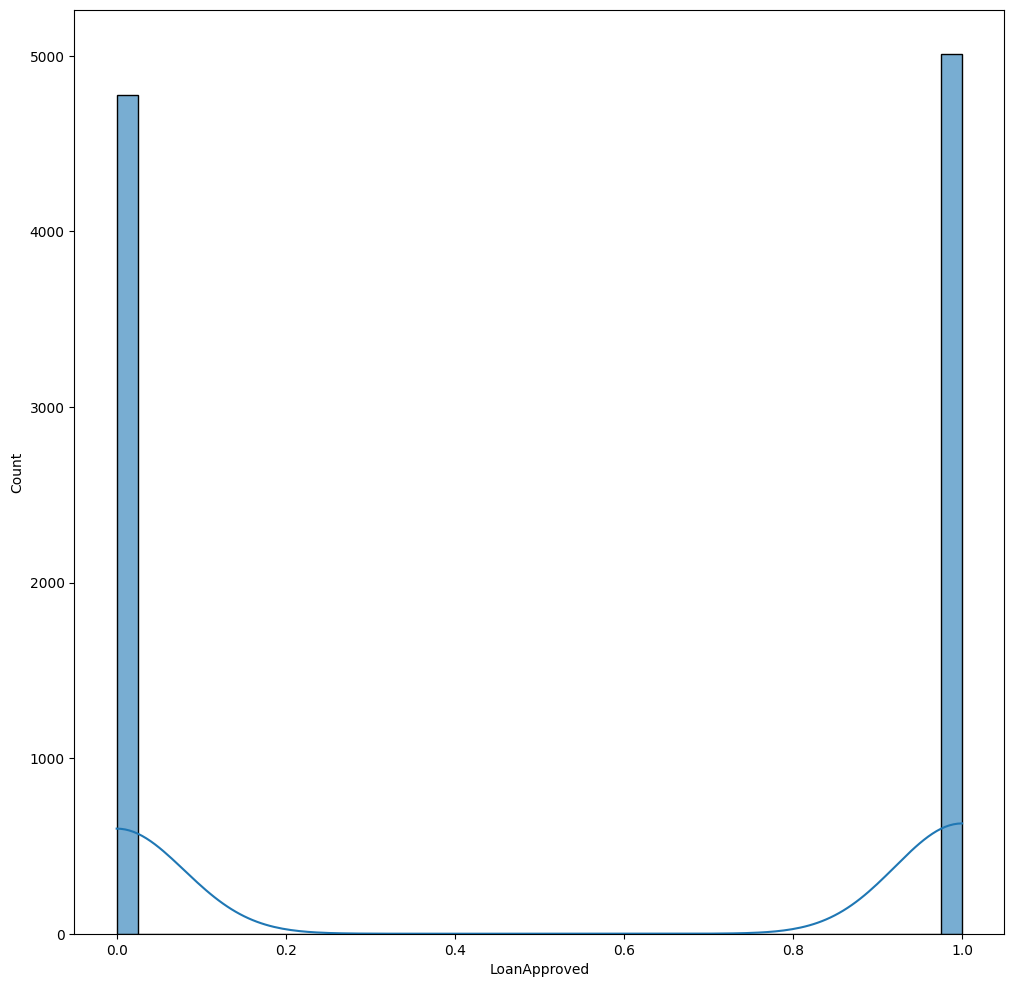

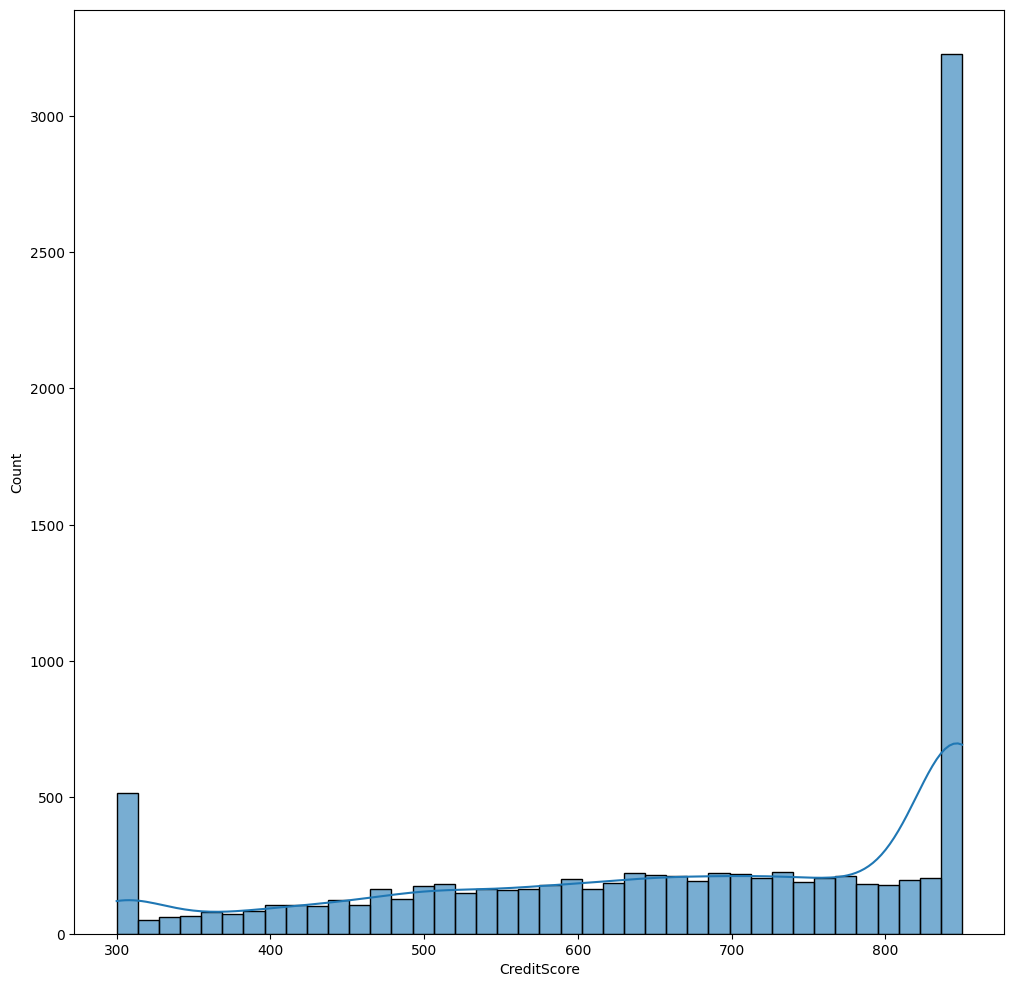

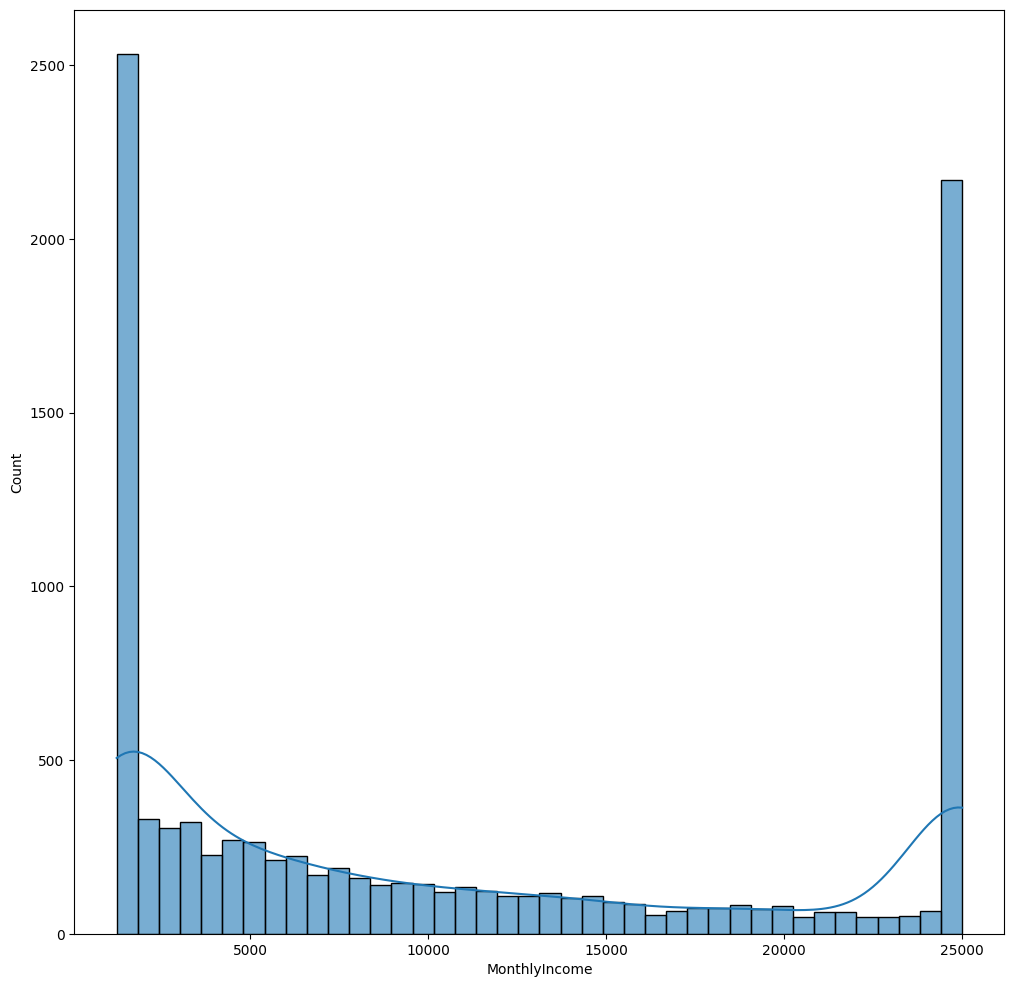

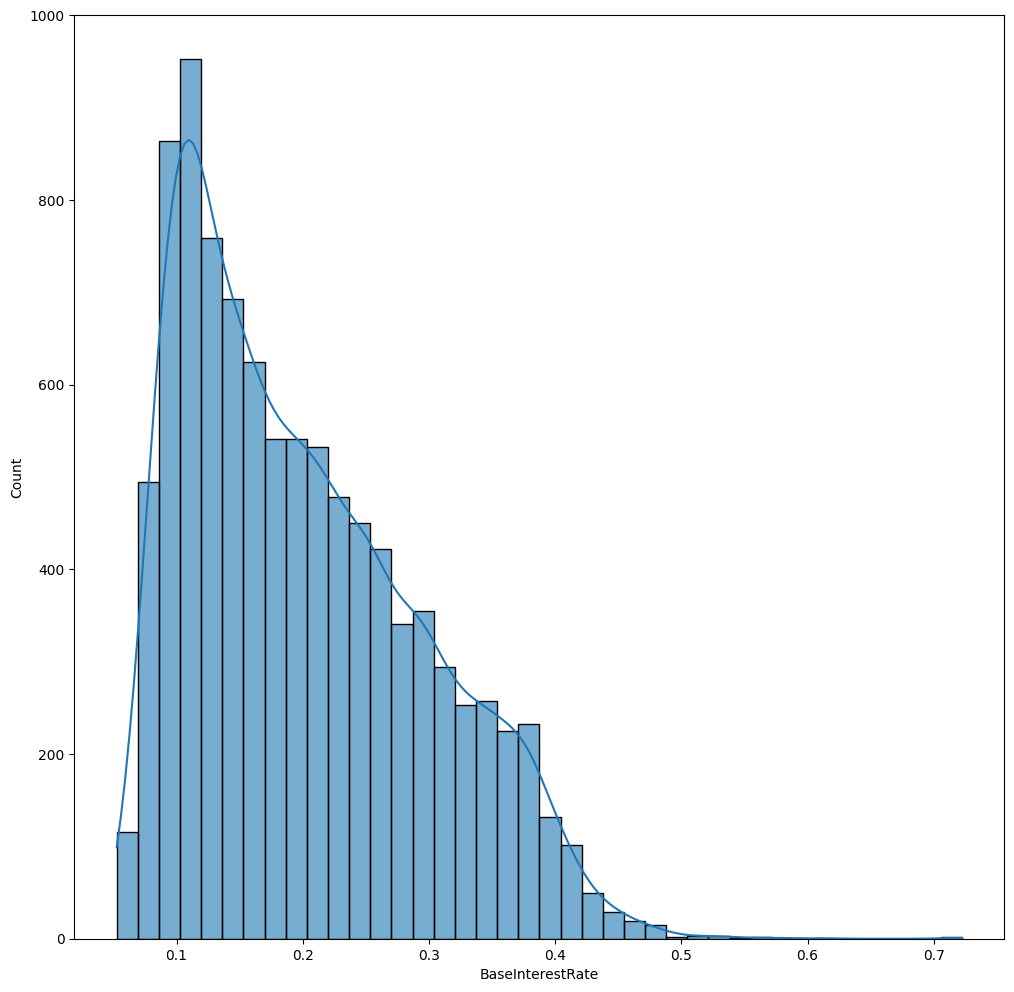

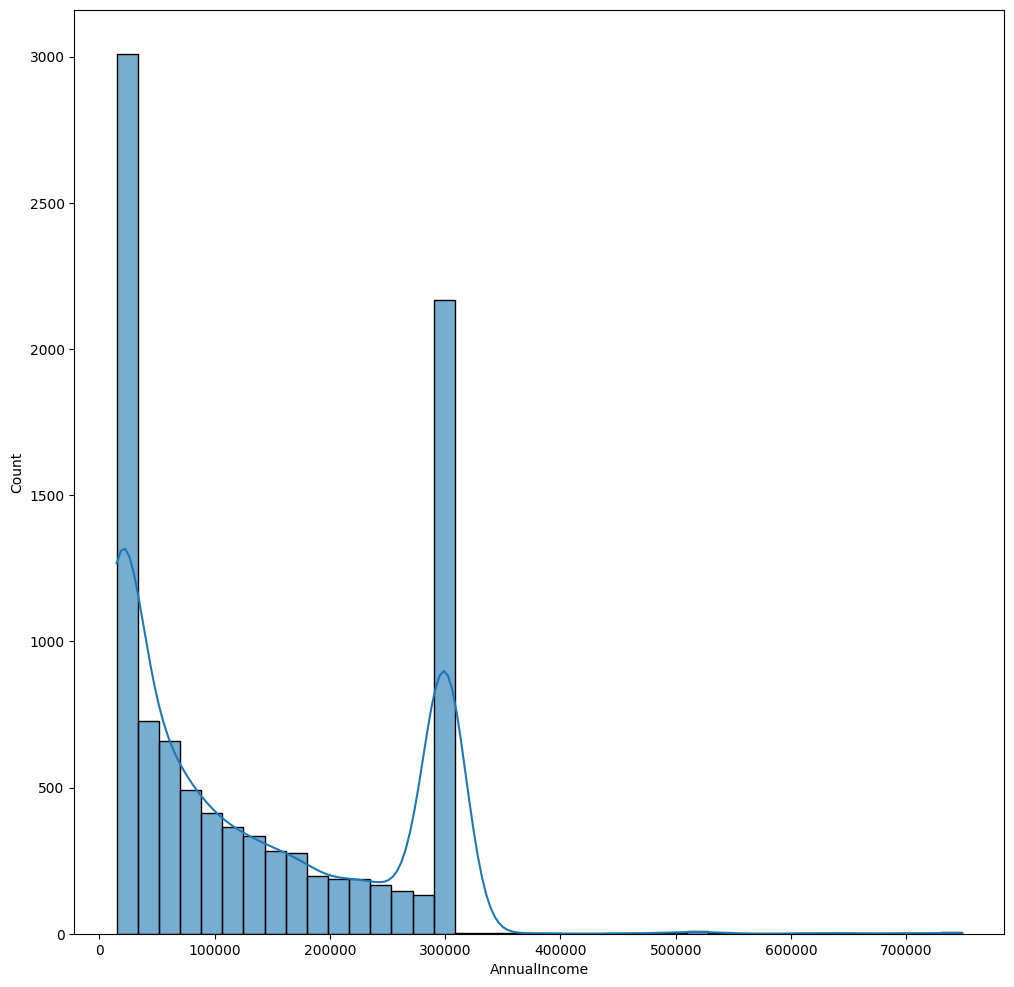

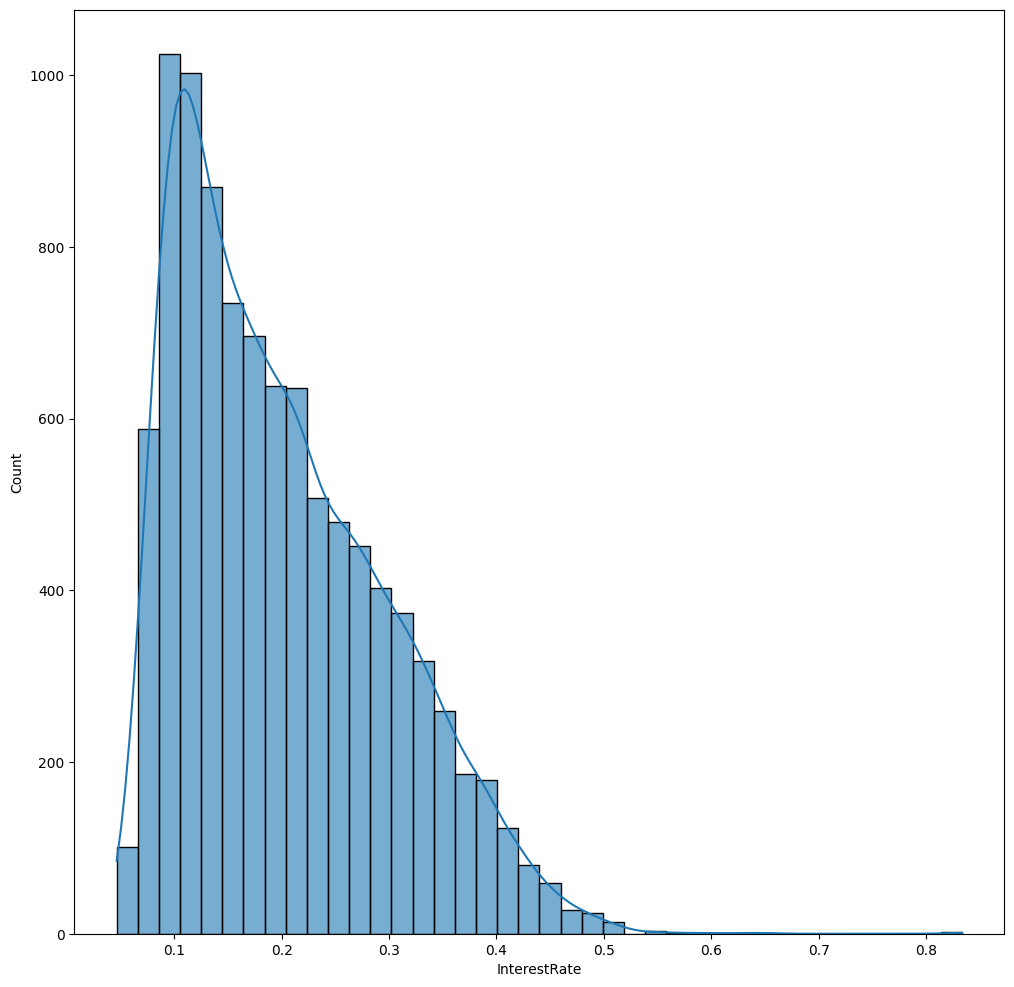

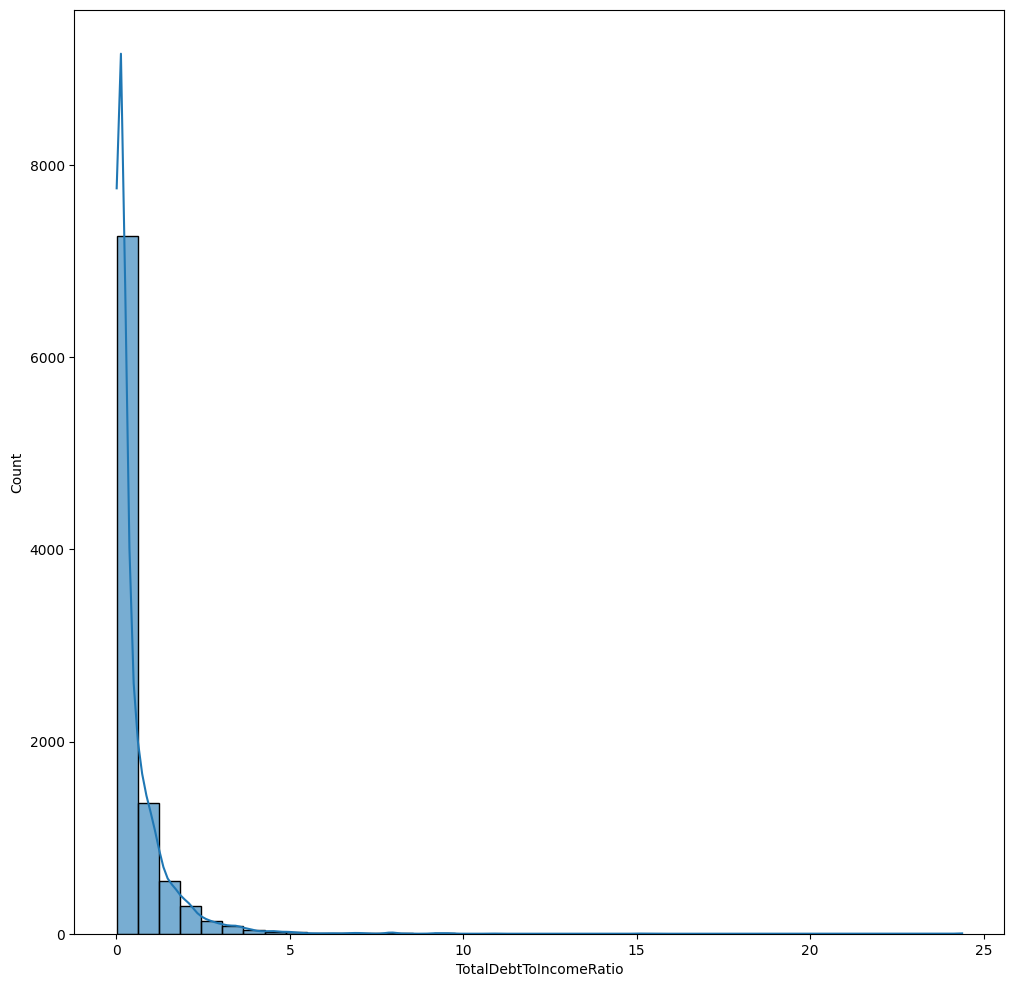

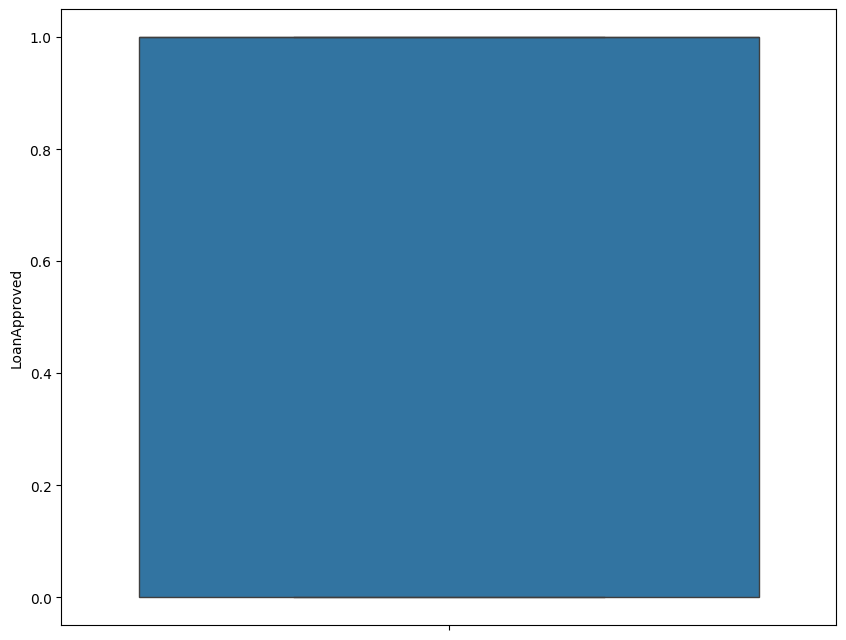

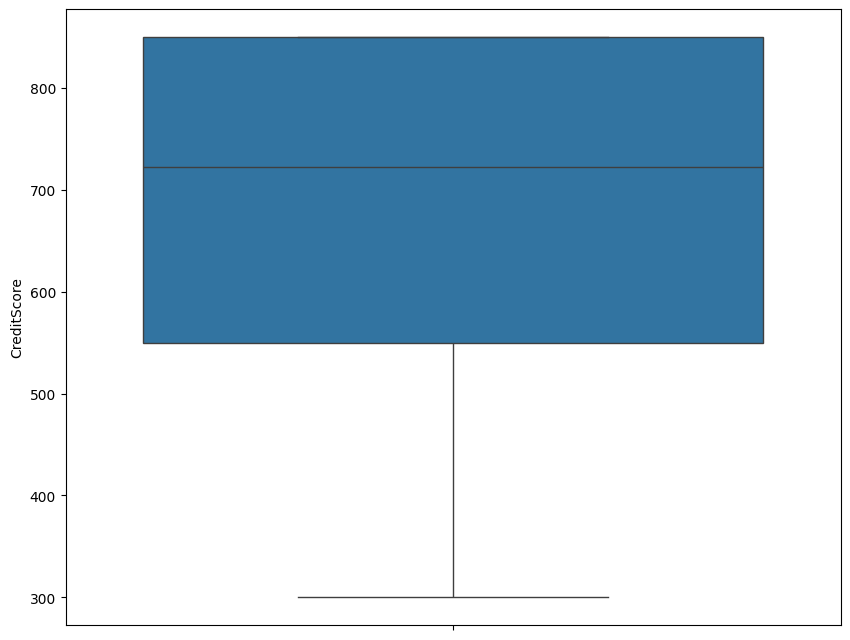

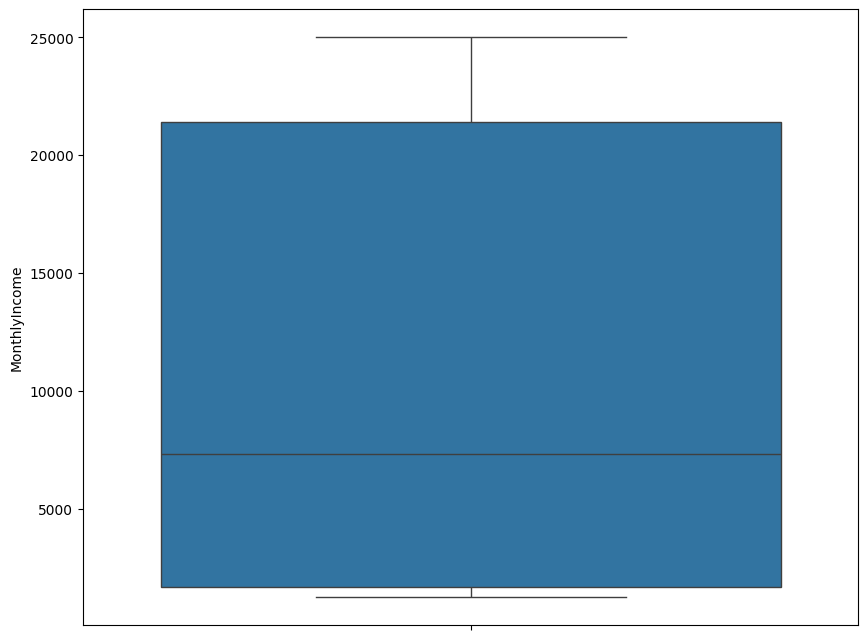

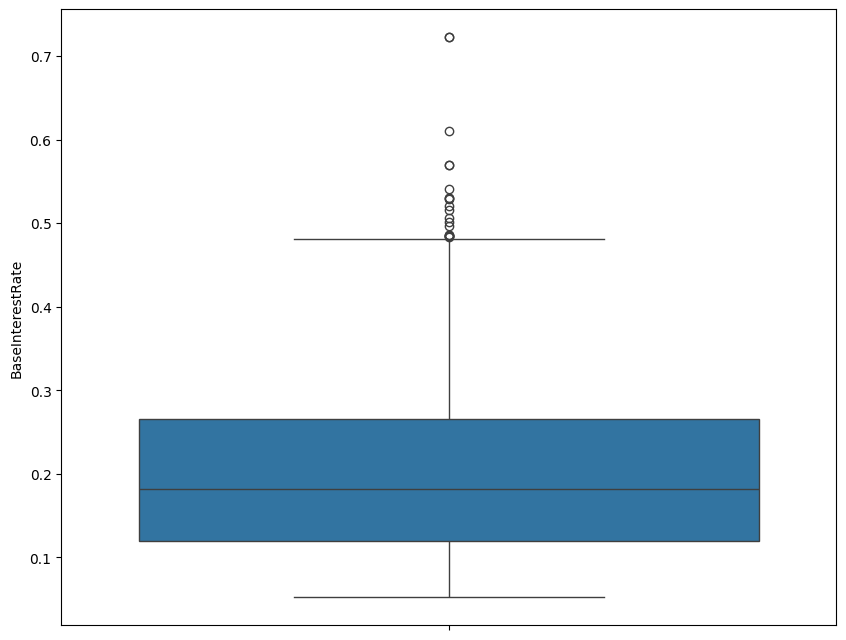

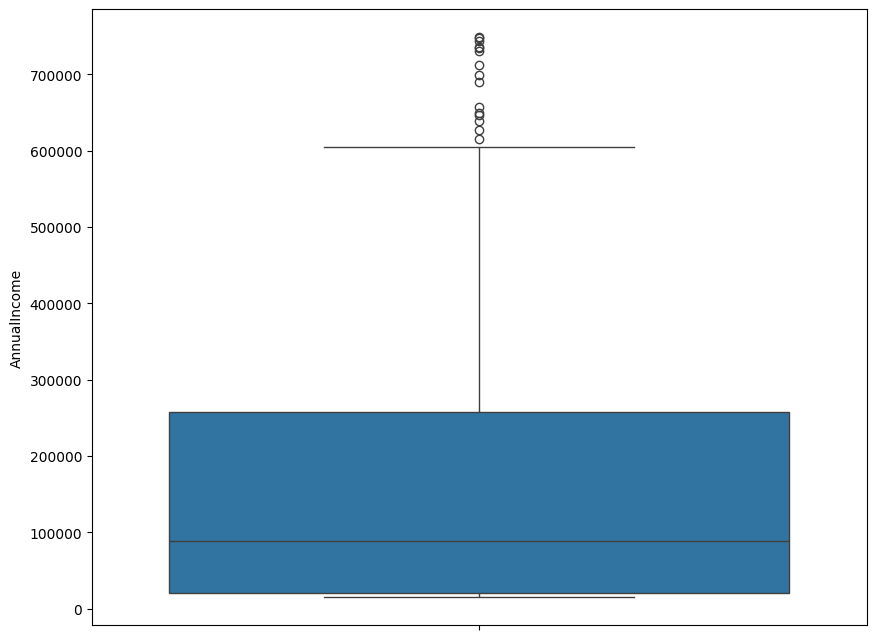

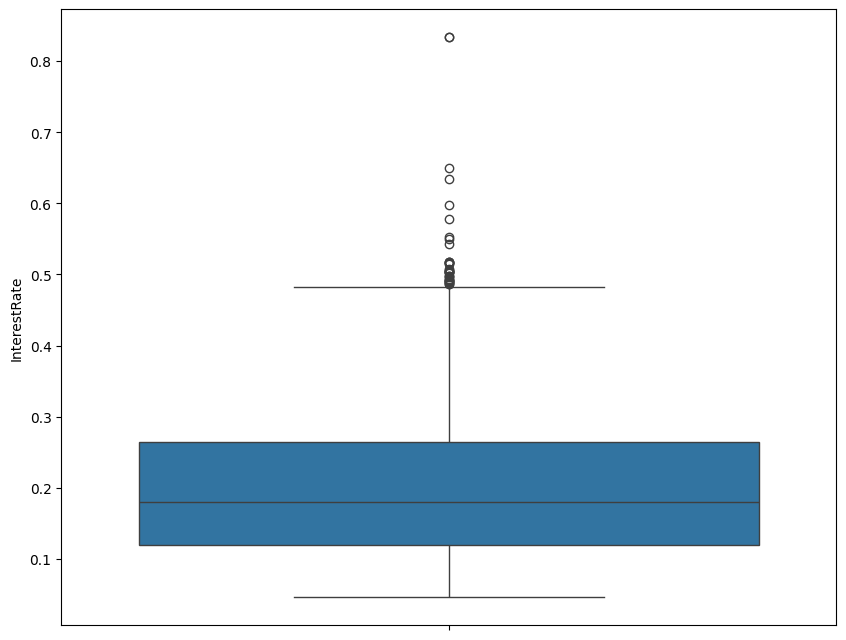

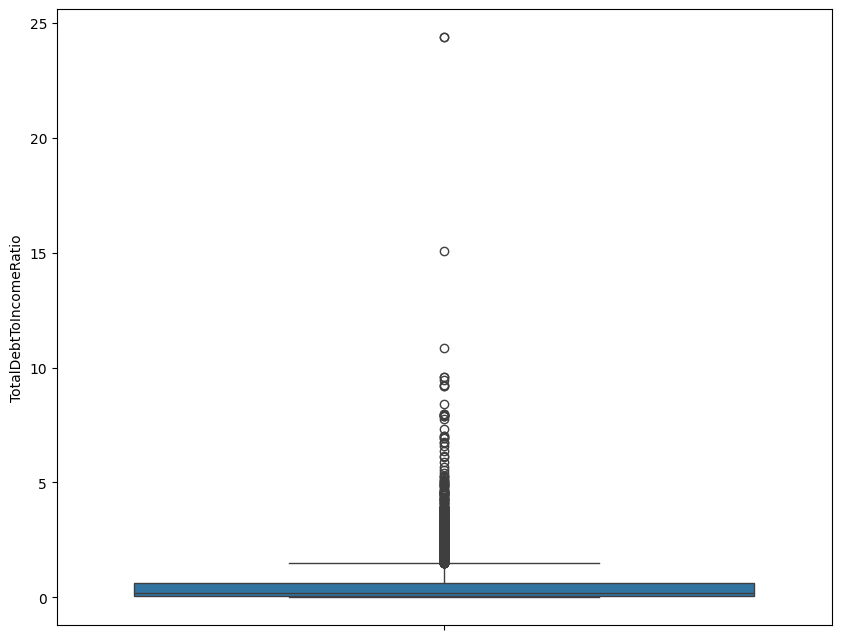

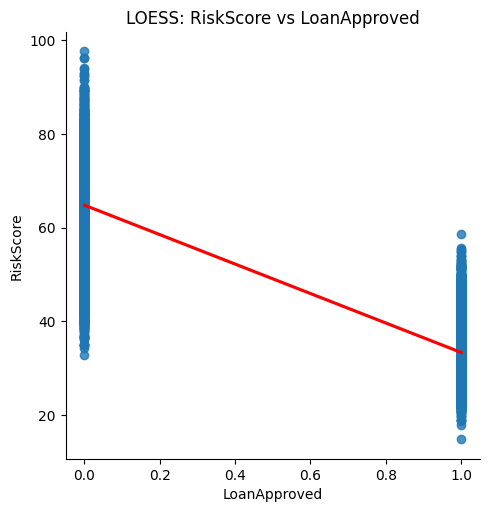

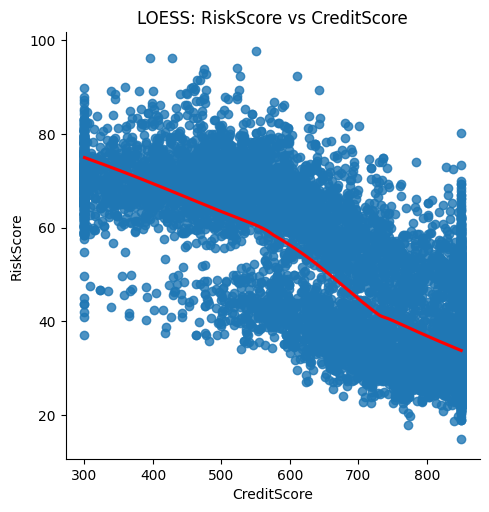

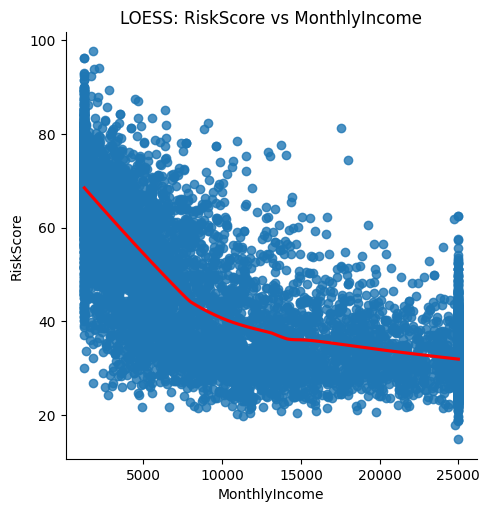

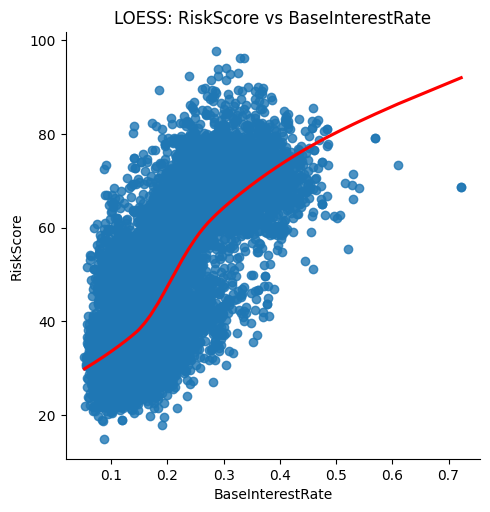

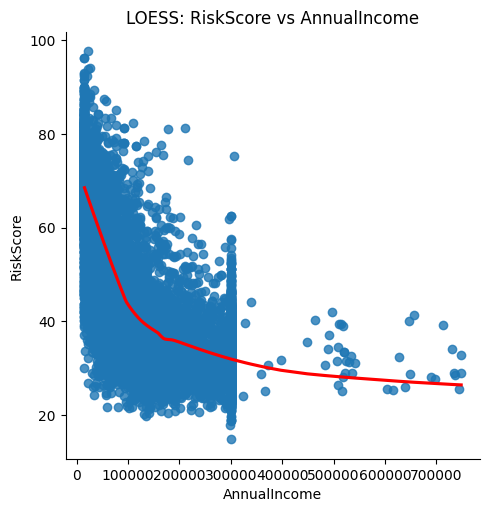

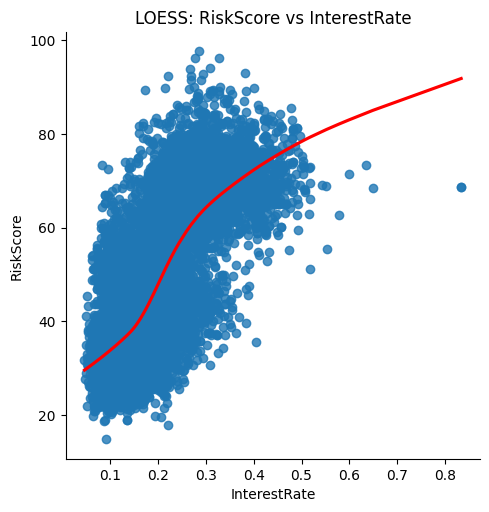

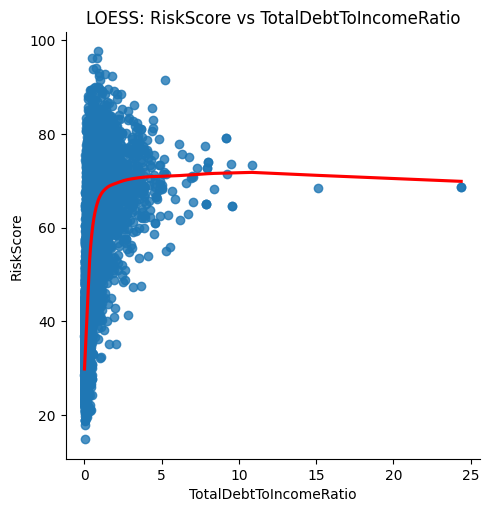

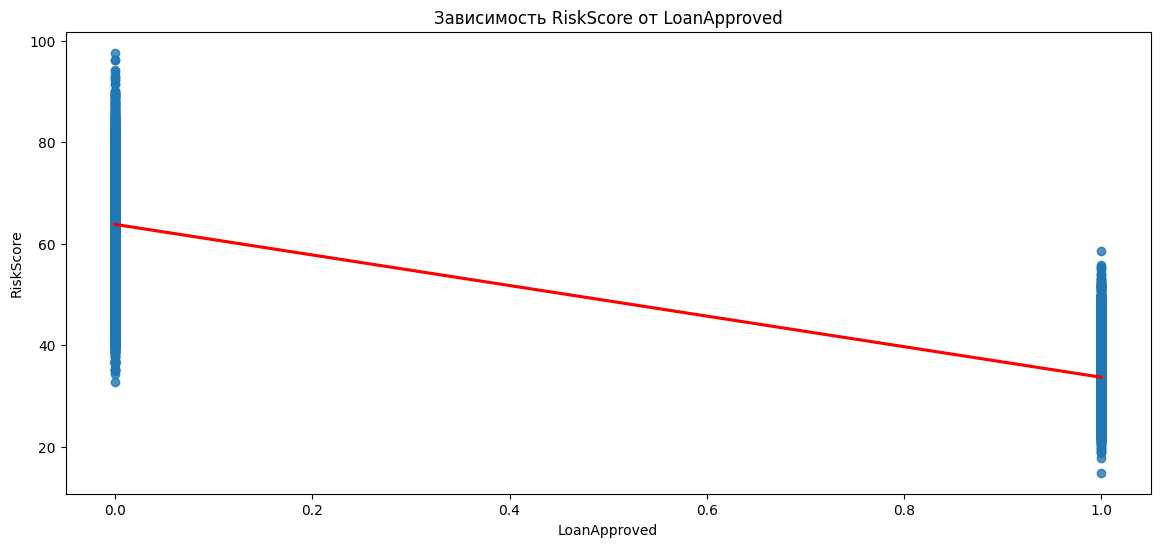

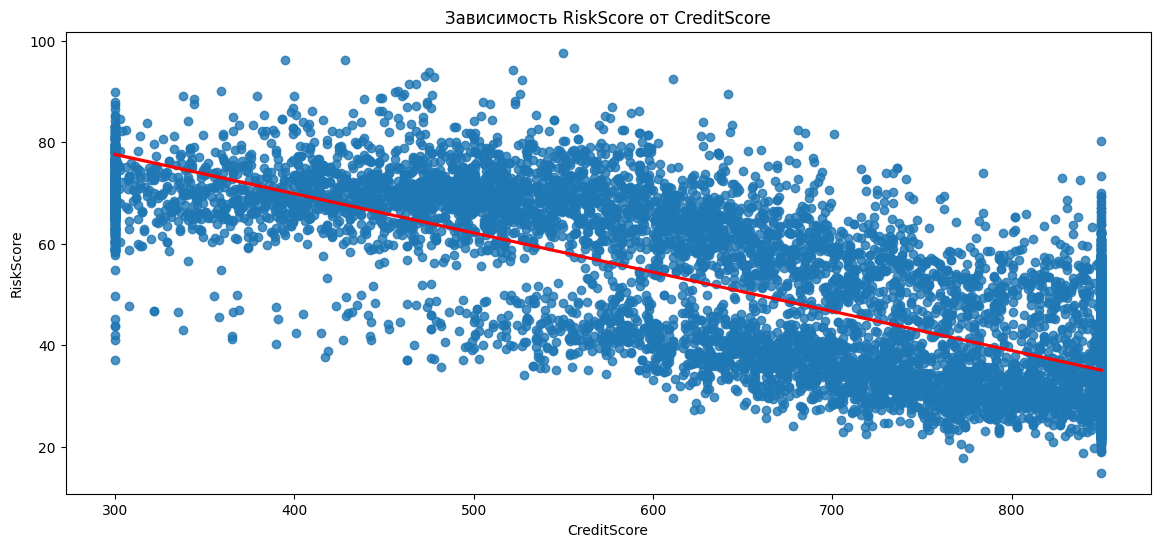

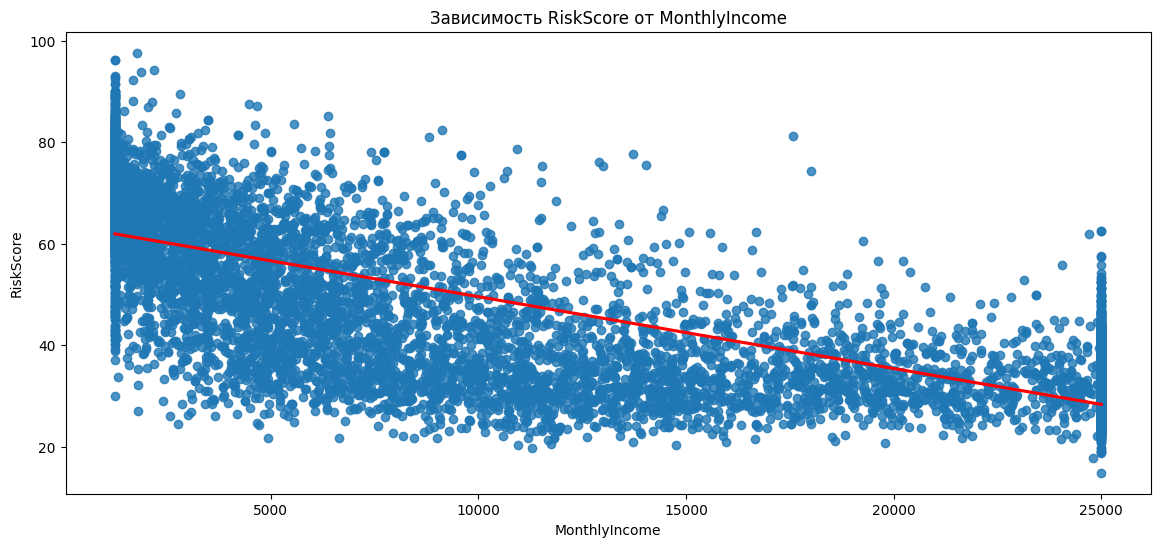

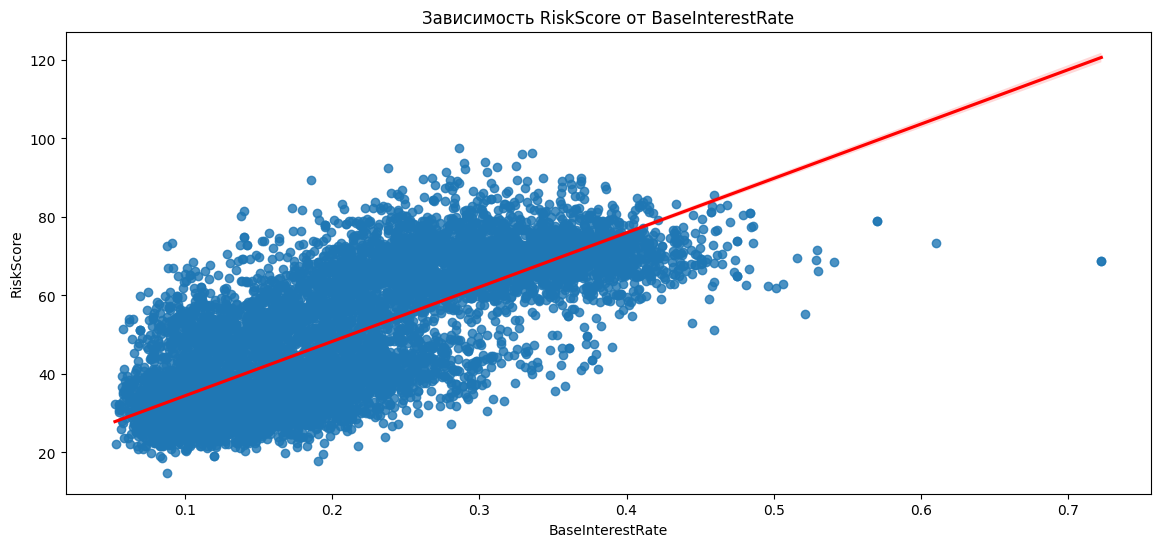

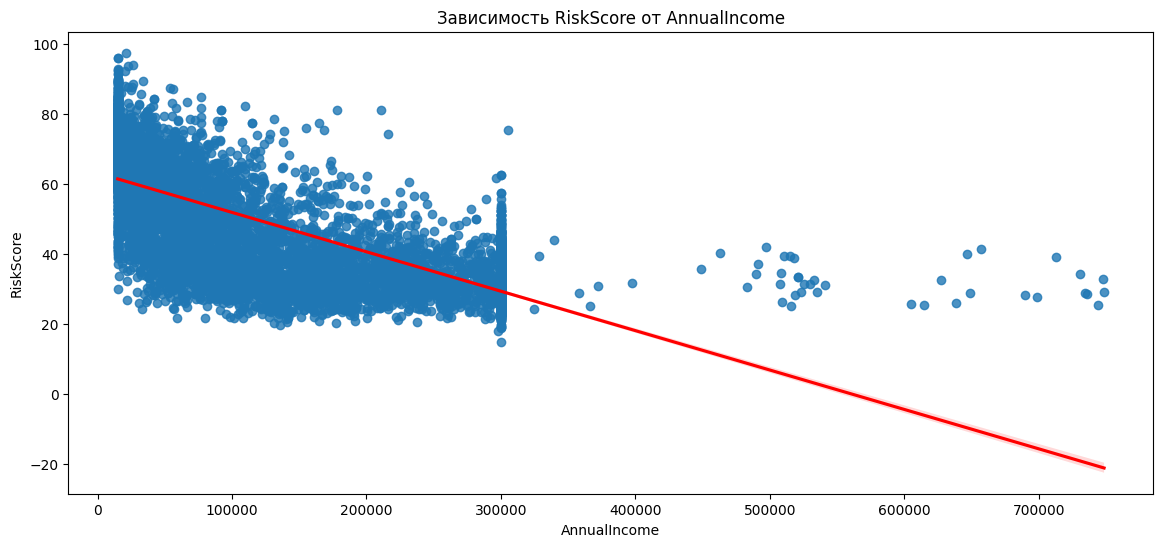

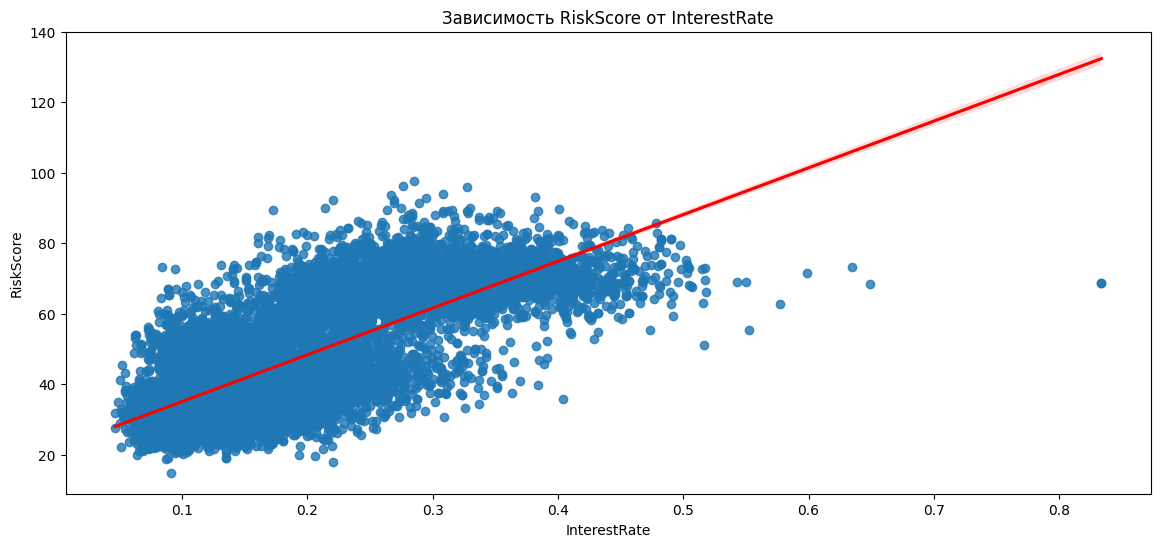

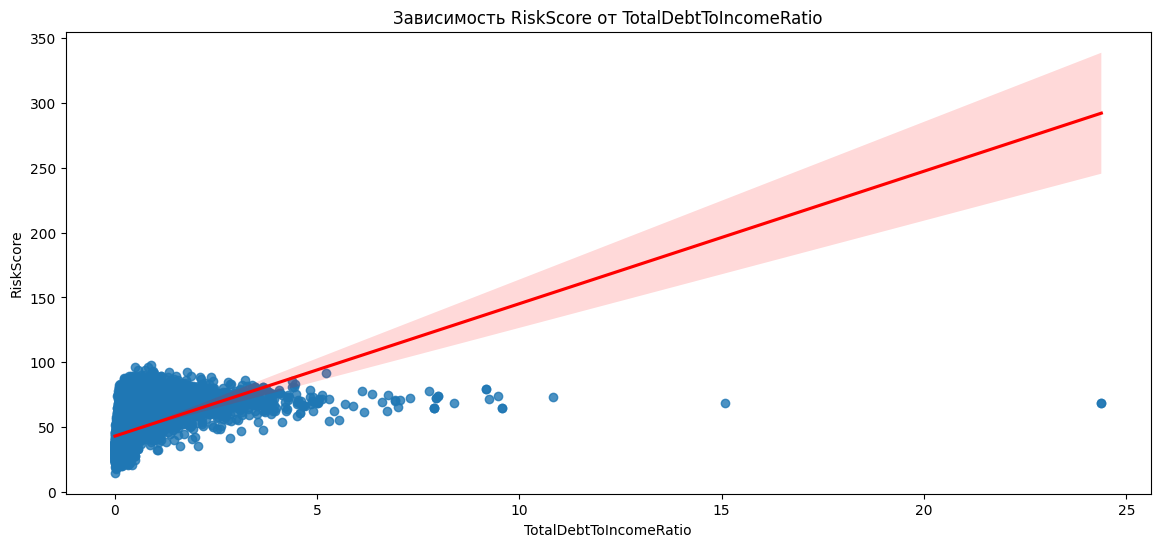

In [73]:
features = ["LoanApproved", "CreditScore", "MonthlyIncome", "BaseInterestRate", "AnnualIncome", "InterestRate", "TotalDebtToIncomeRatio"]

print(df["LoanApproved"].describe())
print(df["CreditScore"].describe())
print(df["MonthlyIncome"].describe())
print(df["BaseInterestRate"].describe())
print(df["AnnualIncome"].describe())
print(df["InterestRate"].describe())
print(df["TotalDebtToIncomeRatio"].describe())

for feature in features:
    plt.figure(figsize=(12, 12))
    sns.histplot(df[feature], bins=40, kde=True, label=feature, alpha=0.6)
    
plt.show()

# Проверим выбросы
for feature in features:
    plt.figure(figsize=(10, 8))
    sns.boxplot(df[feature])

for feature in features :
    sns.lmplot(x=feature, y="RiskScore", data=df, lowess=True, line_kws={"color": "red"})
    plt.title(f"LOESS: RiskScore vs {feature}") # Locally Estimated Scatterplot Smoothing

# метод непараметрической регрессии. LOESS помогает визуализировать тенденции в данных, не предполагая заранее заданной формы зависимости. 
# Для каждой точки данных строится локальная регрессия (обычно полиномиальная, например, 2-й степени) на основе её "соседей".

for feature in features :
    plt.figure(figsize=(14, 6))
    sns.regplot(x=df[feature], y=df["RiskScore"], line_kws={"color": "red"}) 
    plt.title(f"Зависимость RiskScore от {feature}")
    plt.show()




## Попробуем похимичить с данными

In [70]:
# Теперь с MonthlyIncome
print(df['MonthlyIncome'].value_counts().head(10))  # Топ-10 частых значений


# Создаём бинарный признак: 1 или 0 для самых частых значений (таким образом ставим некий индикатор)
df['MonthlyIncome_Is1250'] = (df['MonthlyIncome'] == 1250).astype(int)
df['MonthlyIncome_Is25000'] = (df['MonthlyIncome'] == 25000).astype(int)
df_test['MonthlyIncome_Is1250'] = (df_test['MonthlyIncome'] == 1250).astype(int)
df_test['MonthlyIncome_Is25000'] = (df_test['MonthlyIncome'] == 25000).astype(int)




MonthlyIncome
1250.000000     2222
25000.000000    2124
13860.833333       3
1367.333333        3
11996.666667       3
4838.000000        3
3540.666667        3
3623.583333        3
1921.416667        3
4746.416667        3
Name: count, dtype: int64


In [12]:
# Теперь с AnnualIncome
print(df['AnnualIncome'].value_counts().head(10)) 

df['AnnualIncome_Is15000'] = (df['AnnualIncome'] == 15000).astype(int)
df['AnnualIncome_Is300000'] = (df['AnnualIncome'] == 300000).astype(int)
df_test['AnnualIncome_Is15000'] = (df_test['AnnualIncome'] == 15000).astype(int)
df_test['AnnualIncome_Is300000'] = (df_test['AnnualIncome'] == 300000).astype(int)




AnnualIncome
15000.0     2194
300000.0    2092
166330.0       3
34679.0        3
16408.0        3
143960.0       3
58056.0        3
42488.0        3
43483.0        3
23057.0        3
Name: count, dtype: int64


count    9787.000000
mean      677.911515
std       175.374136
min       300.000000
25%       550.000000
50%       722.000000
75%       850.000000
max       850.000000
Name: CreditScore, dtype: float64
CreditScore
850.0    3045
300.0     475
791.0      26
735.0      26
738.0      25
726.0      25
764.0      24
687.0      23
839.0      23
709.0      23
Name: count, dtype: int64


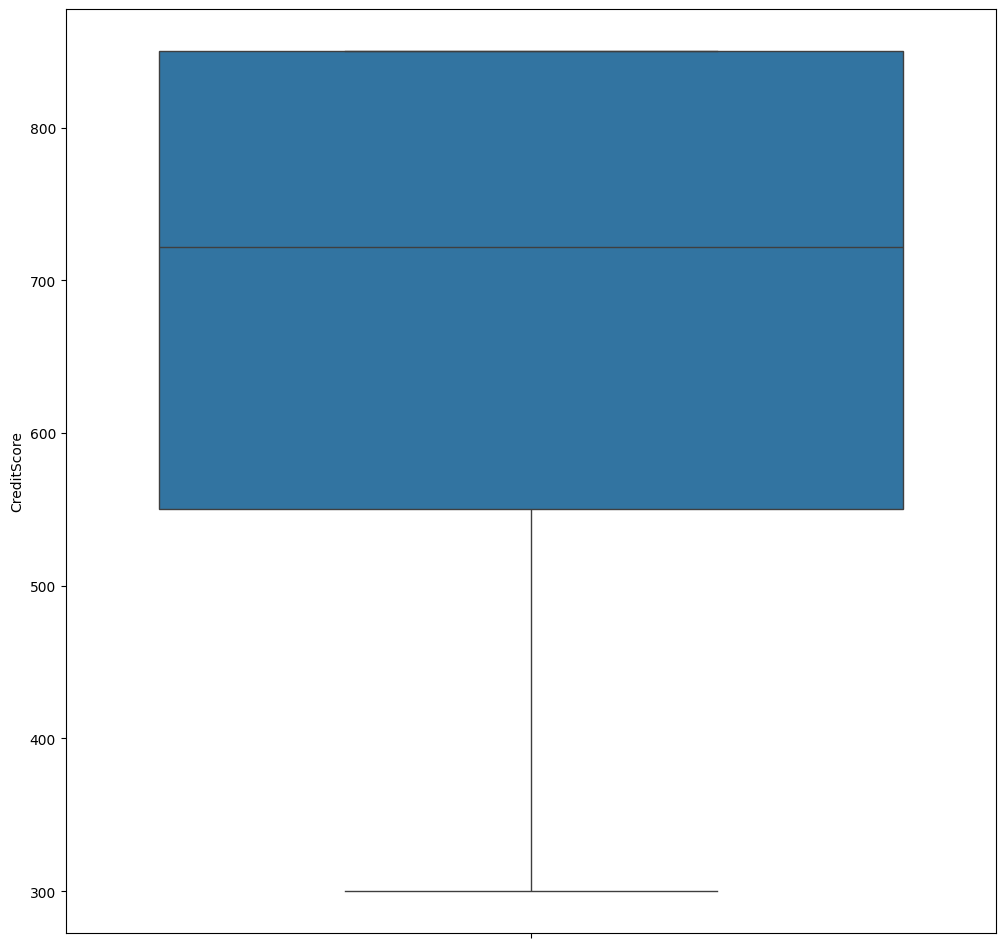

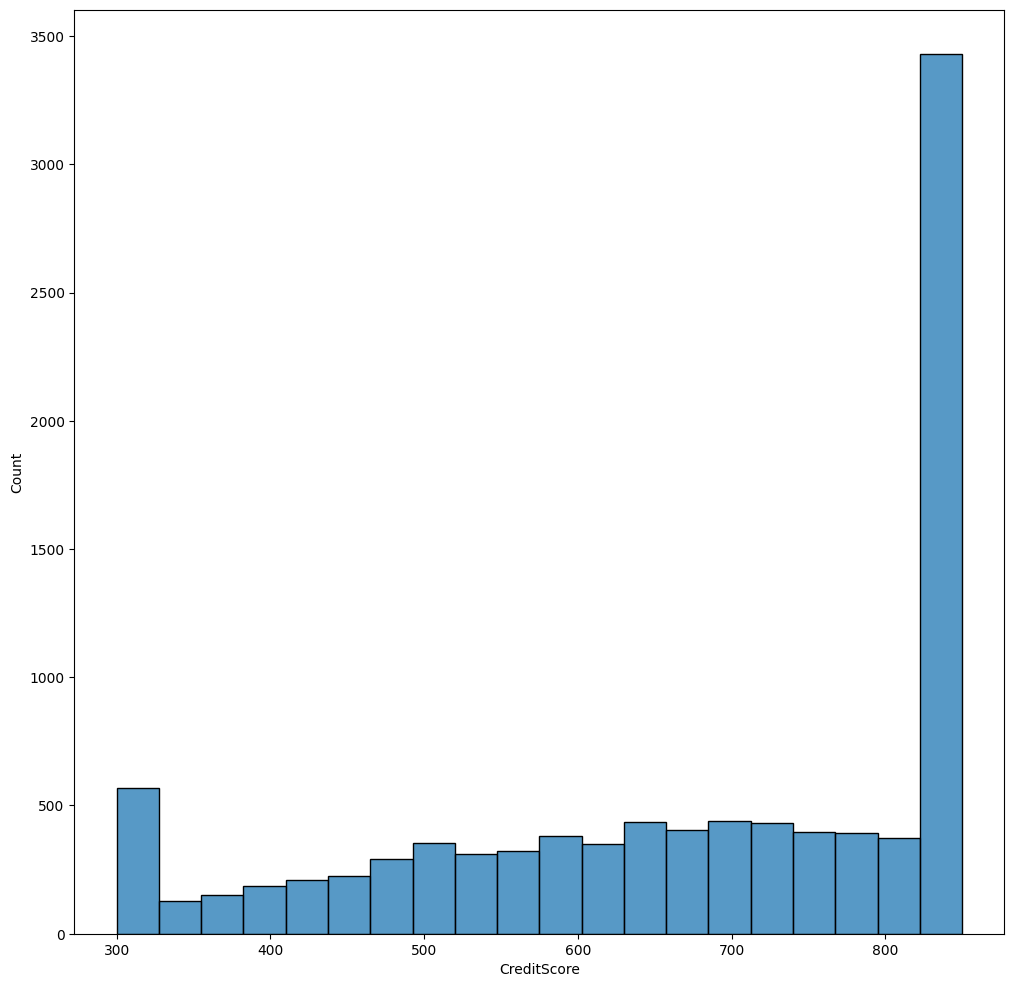

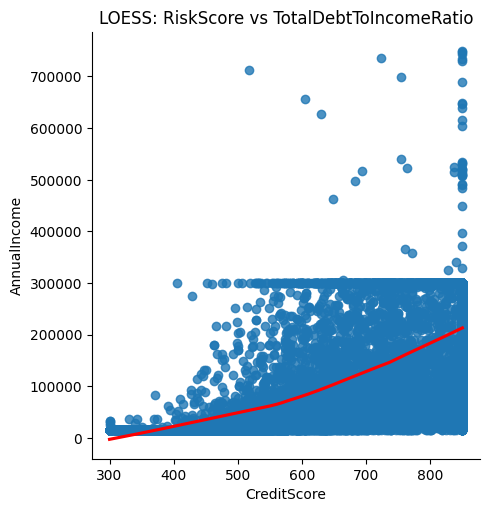

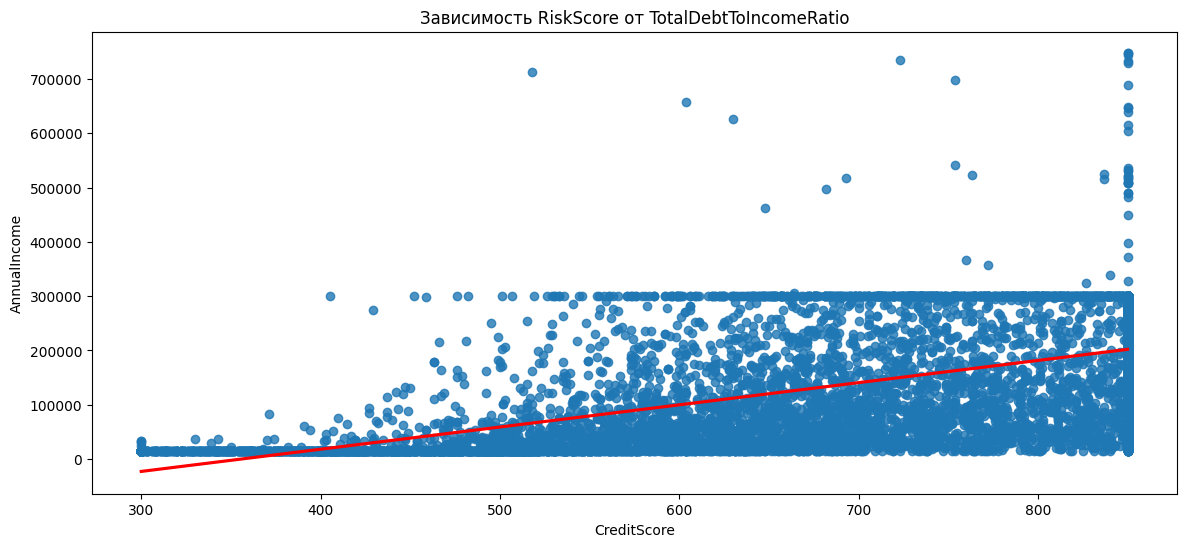

In [71]:
# Теперь с CreditScore

print(df['CreditScore'].describe())
print(df['CreditScore'].value_counts().head(10))  # Топ-10 частых значений

plt.figure(figsize=(12, 12))
sns.boxplot(df["CreditScore"])

plt.figure(figsize=(12, 12))
sns.histplot(df["CreditScore"])

sns.lmplot(x="CreditScore", y="AnnualIncome", data=df, lowess=True, line_kws={"color": "red"})
plt.title(f"LOESS: CreditScore vs AnnualIncome") # Locally Estimated Scatterplot Smoothing

plt.figure(figsize=(14, 6))
sns.regplot(x=df["CreditScore"], y=df["AnnualIncome"], line_kws={"color": "red"}) 
plt.title(f"Зависимость CreditScore от AnnualIncome")
plt.show()

df['CreditScore_Is850'] = (df['CreditScore'] == 850).astype(int)
df['CreditScore_Is300'] = (df['CreditScore'] == 300).astype(int)
df_test['CreditScore_Is850'] = (df_test['CreditScore'] == 850).astype(int)
df_test['CreditScore_Is300'] = (df_test['CreditScore'] == 300).astype(int)

# Трансформации, чтобы "выпрямить" распределение признака и уловить нелинейные зависимости
# уменьшает влияние больших значений
df['CreditScore_Log'] = np.log1p(df['CreditScore'])
df['CreditScore_Sqrt'] = np.sqrt(df['CreditScore'])  
df['CreditScore_Cbrt'] = np.cbrt(df['CreditScore'])  
df_test['CreditScore_Log'] = np.log1p(df_test['CreditScore'])  
df_test['CreditScore_Sqrt'] = np.sqrt(df_test['CreditScore'])  
df_test['CreditScore_Cbrt'] = np.cbrt(df_test['CreditScore'])  


# усиливает различия
df['CreditScore_sq2'] = df['CreditScore'] ** 2 
df['CreditScore_sq3'] = df['CreditScore'] ** 3
df_test['CreditScore_sq2'] = df_test['CreditScore'] ** 2
df_test['CreditScore_sq3'] = df_test['CreditScore'] ** 3

df['CreditScore_AnnualIncome'] = df['CreditScore'] * df['AnnualIncome']
df_test['CreditScore_AnnualIncome'] = df_test['CreditScore'] * df_test['AnnualIncome']
df['CreditScore_AnnualIncome05'] = df['CreditScore_AnnualIncome'] ** 0.5
df_test['CreditScore_AnnualIncome05'] = df_test['CreditScore_AnnualIncome'] ** 0.5
df['CreditScore_AnnualIncome2'] = df['CreditScore_AnnualIncome'] ** 2
df_test['CreditScore_AnnualIncome2'] = df_test['CreditScore_AnnualIncome'] ** 2
df['CreditScore_AnnualIncome3'] = df['CreditScore_AnnualIncome'] ** 3
df_test['CreditScore_AnnualIncome3'] = df_test['CreditScore_AnnualIncome'] ** 3


df['CreditScore_DTI'] = df['CreditScore'] / (df['TotalDebtToIncomeRatio'] + 1) # как кредитный рейтинг "компенсируется" высокой долговой нагрузкой
df_test['CreditScore_DTI'] = df_test['CreditScore'] / (df_test['TotalDebtToIncomeRatio'] + 1)



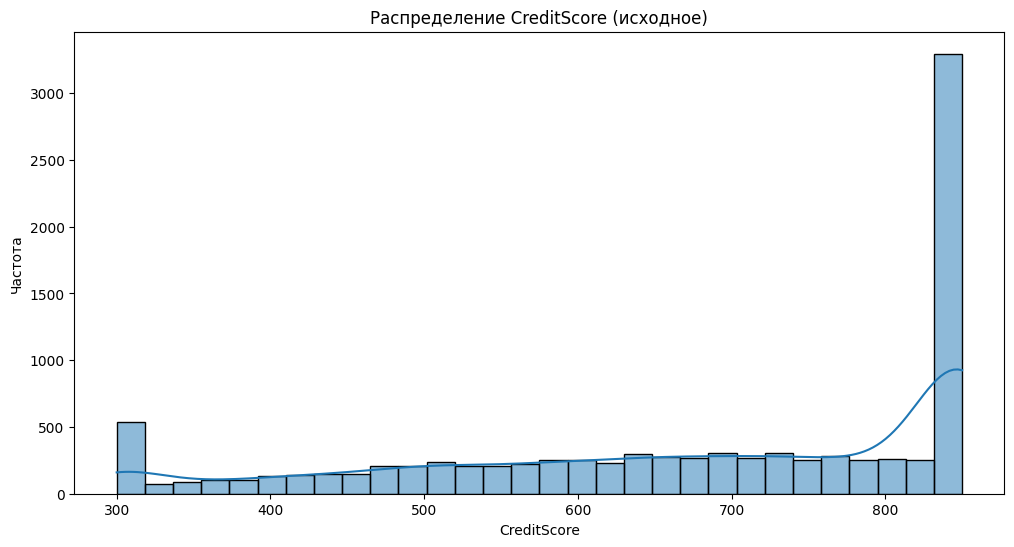

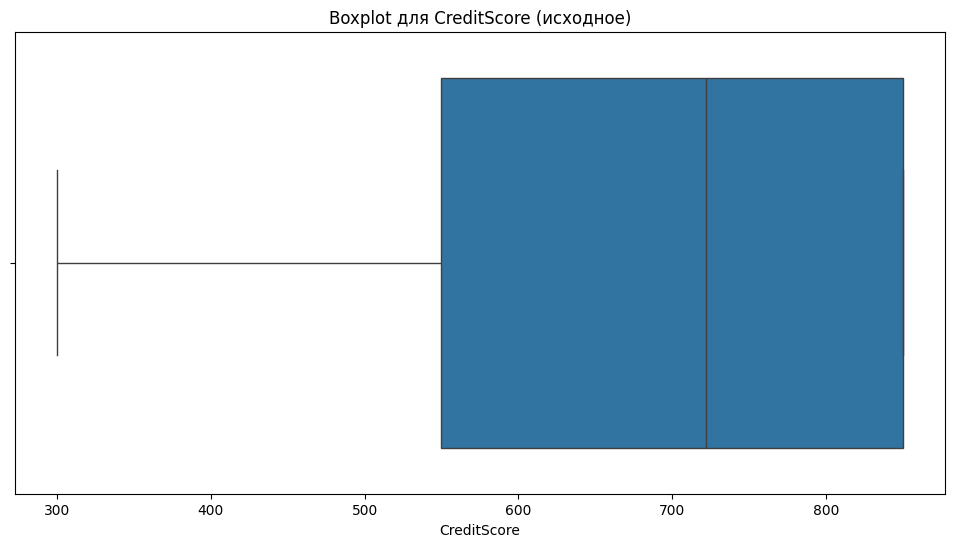

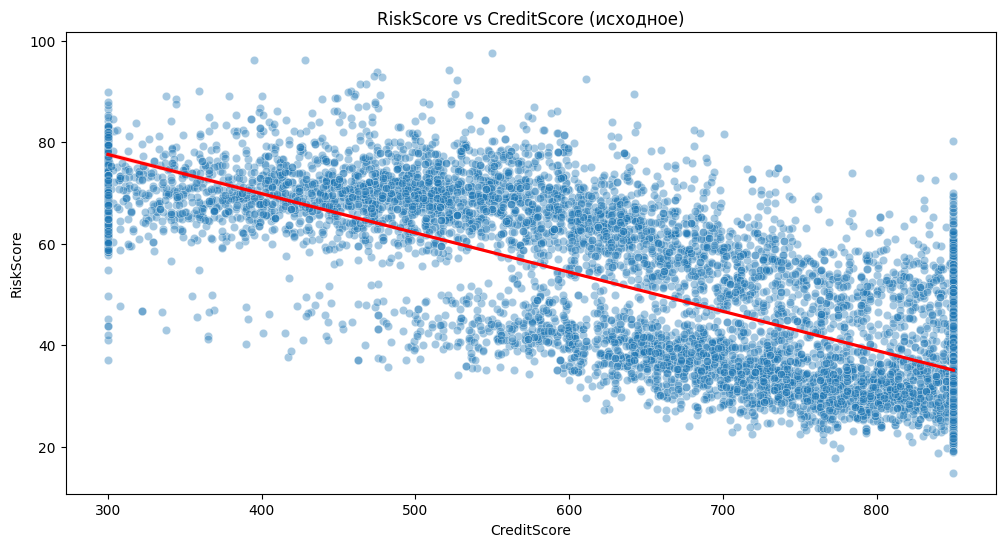

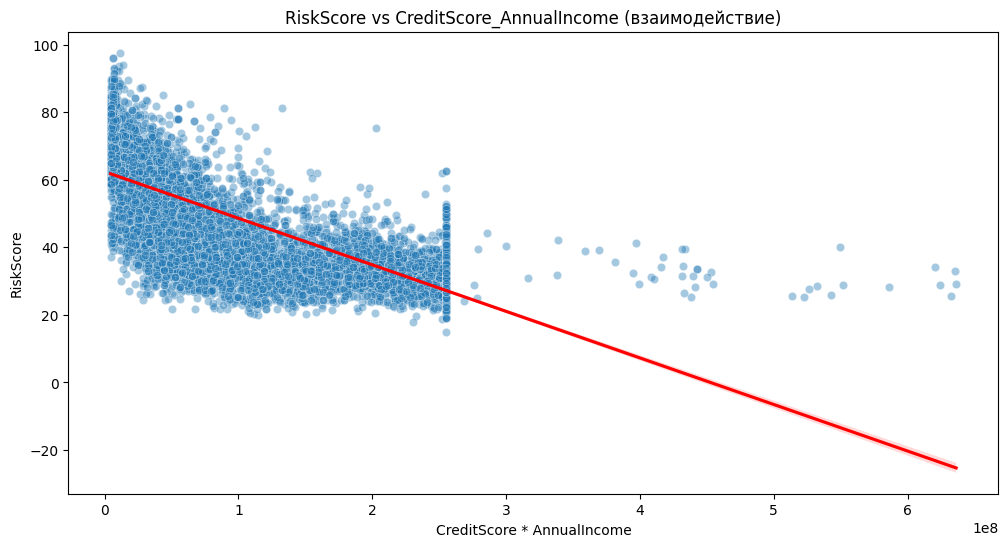

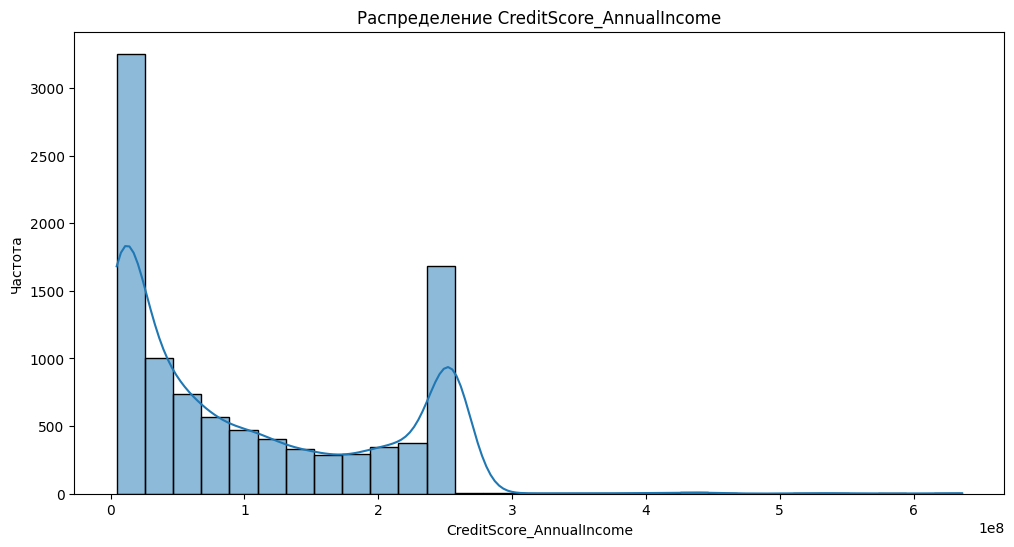

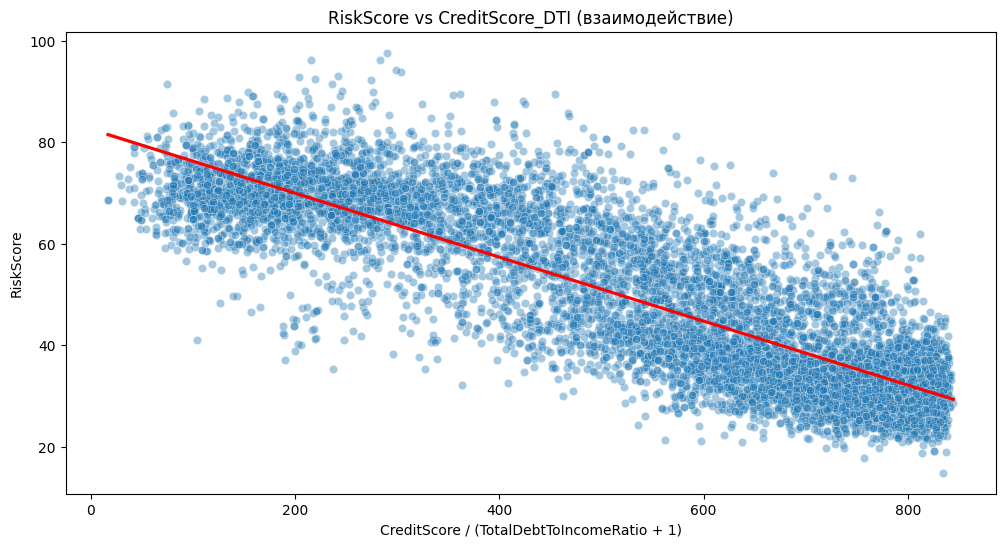

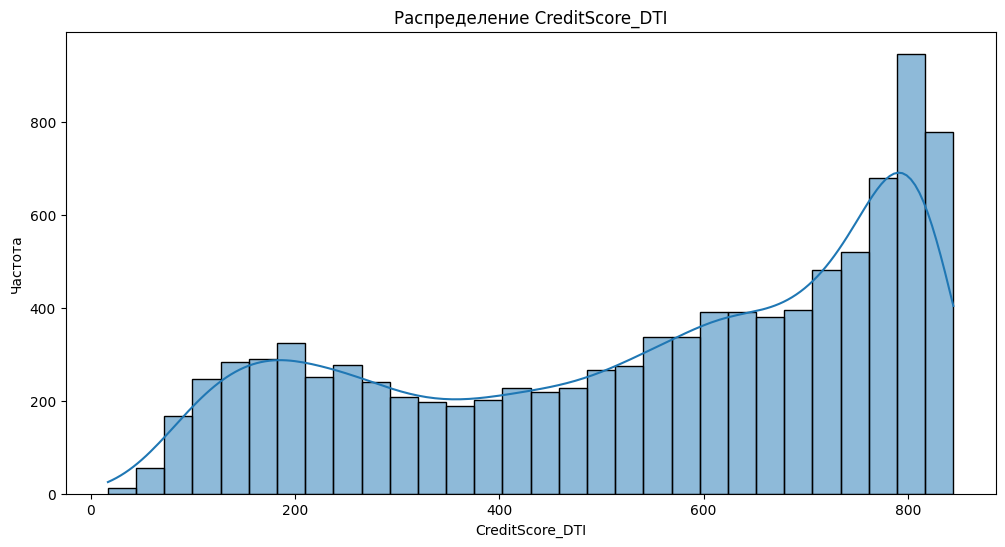

In [72]:

plt.figure(figsize=(12, 6))
sns.histplot(df['CreditScore'], bins=30, kde=True)
plt.title("Распределение CreditScore (исходное)")
plt.xlabel("CreditScore")
plt.ylabel("Частота")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df["CreditScore"])
plt.title("Boxplot для CreditScore (исходное)")
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['CreditScore'], y=df['RiskScore'], alpha=0.4)
sns.regplot(x=df['CreditScore'], y=df['RiskScore'], scatter=False, color='red')
plt.title("RiskScore vs CreditScore (исходное)")
plt.xlabel("CreditScore")
plt.ylabel("RiskScore")
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['CreditScore_AnnualIncome'], y=df['RiskScore'], alpha=0.4)
sns.regplot(x=df['CreditScore_AnnualIncome'], y=df['RiskScore'], scatter=False, color='red')
plt.title("RiskScore vs CreditScore_AnnualIncome (взаимодействие)")
plt.xlabel("CreditScore * AnnualIncome")
plt.ylabel("RiskScore")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df['CreditScore_AnnualIncome'], bins=30, kde=True)
plt.title("Распределение CreditScore_AnnualIncome")
plt.xlabel("CreditScore_AnnualIncome")
plt.ylabel("Частота")
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['CreditScore_DTI'], y=df['RiskScore'], alpha=0.4)
sns.regplot(x=df['CreditScore_DTI'], y=df['RiskScore'], scatter=False, color='red')
plt.title("RiskScore vs CreditScore_DTI (взаимодействие)")
plt.xlabel("CreditScore / (TotalDebtToIncomeRatio + 1)")
plt.ylabel("RiskScore")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df['CreditScore_DTI'], bins=30, kde=True)
plt.title("Распределение CreditScore_DTI")
plt.xlabel("CreditScore_DTI")
plt.ylabel("Частота")
plt.show()

In [15]:


df["BaseInterestRate_AnnualIncome"] = df['AnnualIncome'] * df["BaseInterestRate"]
df_test["BaseInterestRate_AnnualIncome"] = df_test['AnnualIncome'] * df_test["BaseInterestRate"]

features = ["AnnualIncome", "MonthlyLoanPayment", "LoanAmount", 'NetWorth', "TotalAssets"]

for feature in features:
    df[f'Log_{feature}'] = np.log1p(df[feature])
    df_test[f'Log_{feature}'] = np.log1p(df_test[feature])




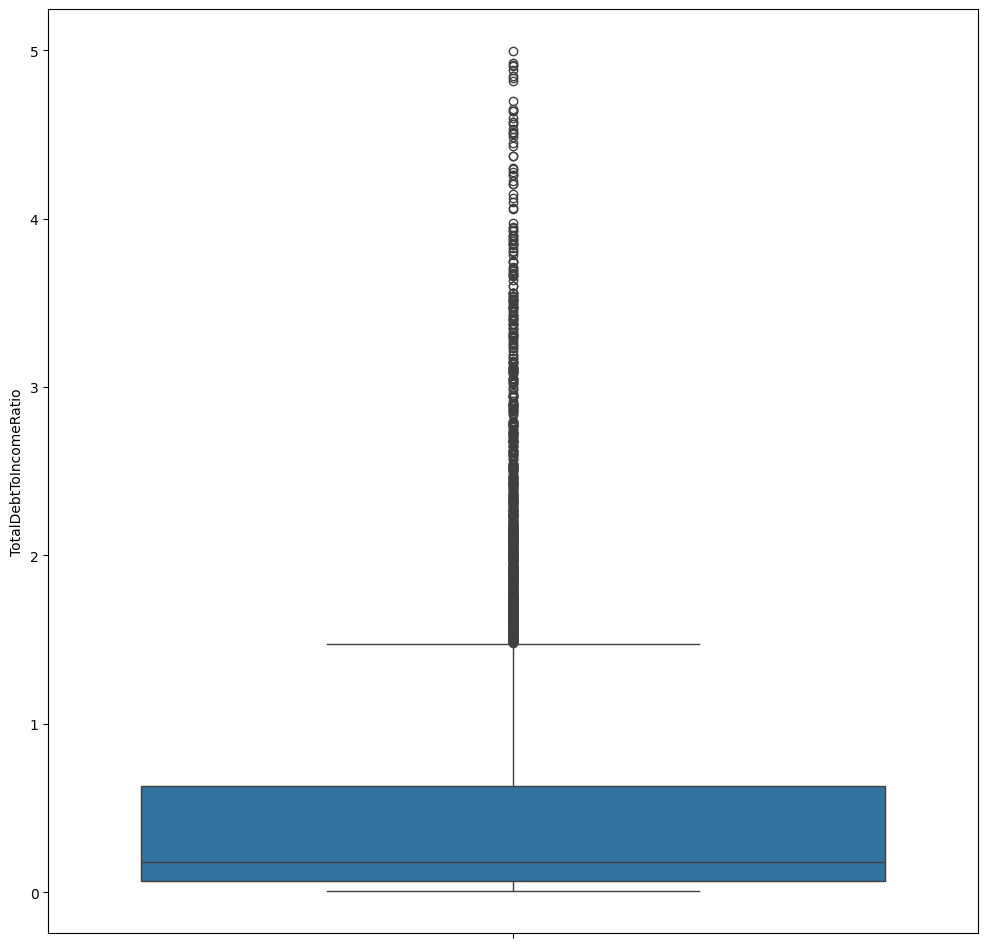

In [16]:
# Начнем с TotalDebtTolncomeRatio

# Уберем все что больше 5
df = df[df["TotalDebtToIncomeRatio"] < 5]

plt.figure(figsize=(12, 12))
sns.boxplot(df["TotalDebtToIncomeRatio"])

# Т.к связ между RiskScore и TotalDebtToIncomeRatio нелинейная, то надо полиномиально или логарифмом преобразовывать наши фичи

df["TotalDebtToIncomeRatio_sqrt3"] = np.cbrt(df['TotalDebtToIncomeRatio'])
df_test['TotalDebtToIncomeRatio_sqrt3'] = np.cbrt(df_test['TotalDebtToIncomeRatio'])

df["TotalDebtToIncomeRatio_sqrt2"] = np.sqrt(df['TotalDebtToIncomeRatio'])
df_test['TotalDebtToIncomeRatio_sqrt2'] = np.sqrt(df_test['TotalDebtToIncomeRatio'])

df["TotalDebtToIncomeRatio_log"] = np.log1p(df['TotalDebtToIncomeRatio']) 
df_test['TotalDebtToIncomeRatio_log'] = np.log1p(df_test['TotalDebtToIncomeRatio'])

# как качество кредитного рейтинга (CreditScore) сочетается с долговой нагрузкой.
df["CreditScore_TotalDebtToIncomeRatio"] = df["CreditScore"] * df["TotalDebtToIncomeRatio"]
df_test["CreditScore_TotalDebtToIncomeRatio"] = df_test["CreditScore"] * df_test["TotalDebtToIncomeRatio"]

# насколько доступным является кредит относительно дохода заемщика
df["Income_LoanAmount_Interaction"] = df["MonthlyIncome"] * df["LoanAmount"]
df_test["Income_LoanAmount_Interaction"] = df_test["MonthlyIncome"] * df_test["LoanAmount"]

df["Log_CreditScore_TotalDebtToIncomeRatio"] = np.log1p(df["CreditScore"]) * df["TotalDebtToIncomeRatio"]
df_test["Log_CreditScore_TotalDebtToIncomeRatio"] = np.log1p(df_test["CreditScore"]) * df_test["TotalDebtToIncomeRatio"]

# как долговая нагрузка сочетается с условиями кредитования
df["Debt_Interest_Interaction"] = df["TotalDebtToIncomeRatio"] * df["InterestRate"]
df_test["Debt_Interest_Interaction"] = df_test["TotalDebtToIncomeRatio"] * df_test["InterestRate"]



Text(0.5, 1.0, 'LOESS: RiskScore vs TotalDebtToIncomeRatio_log')

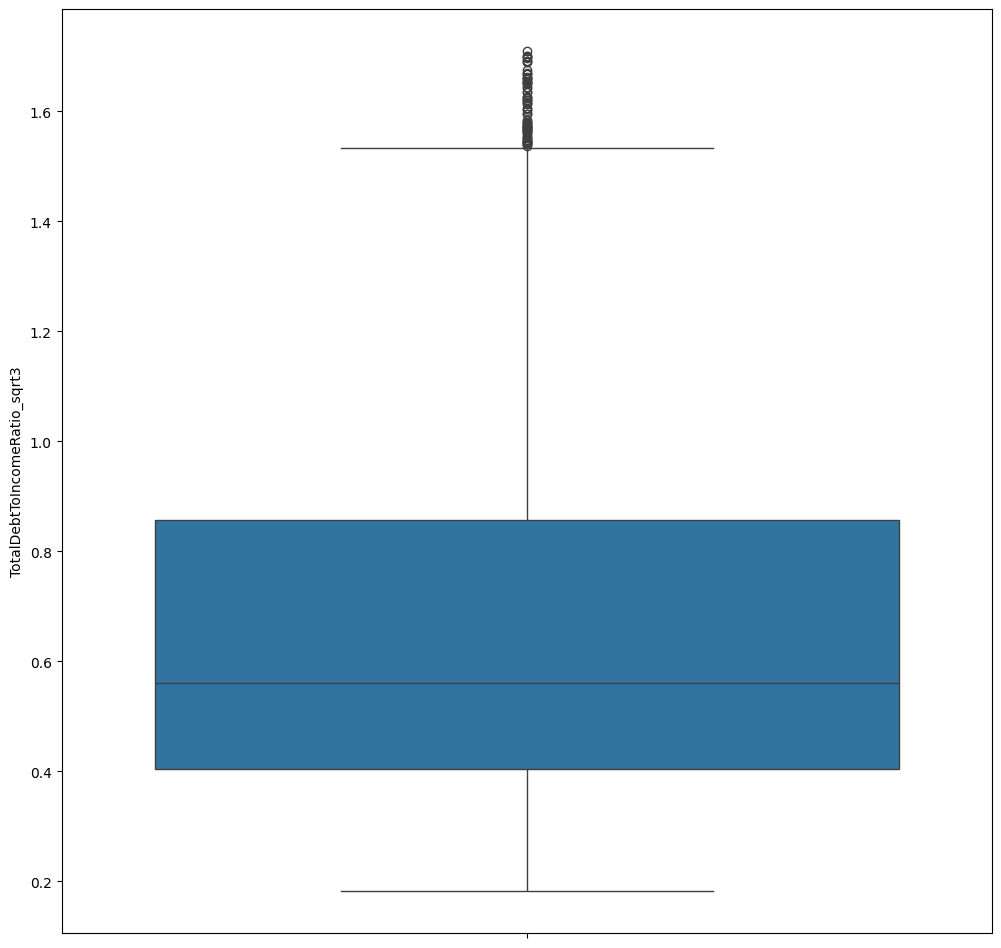

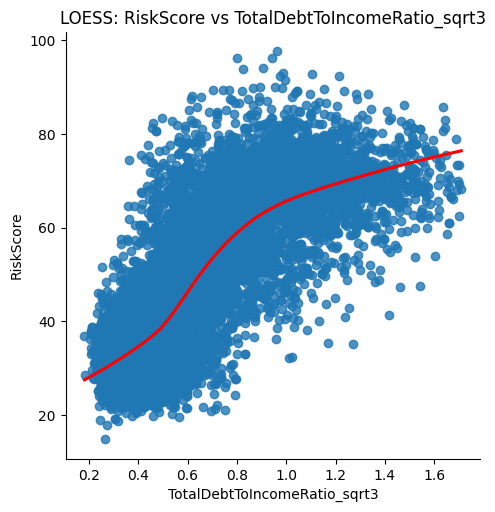

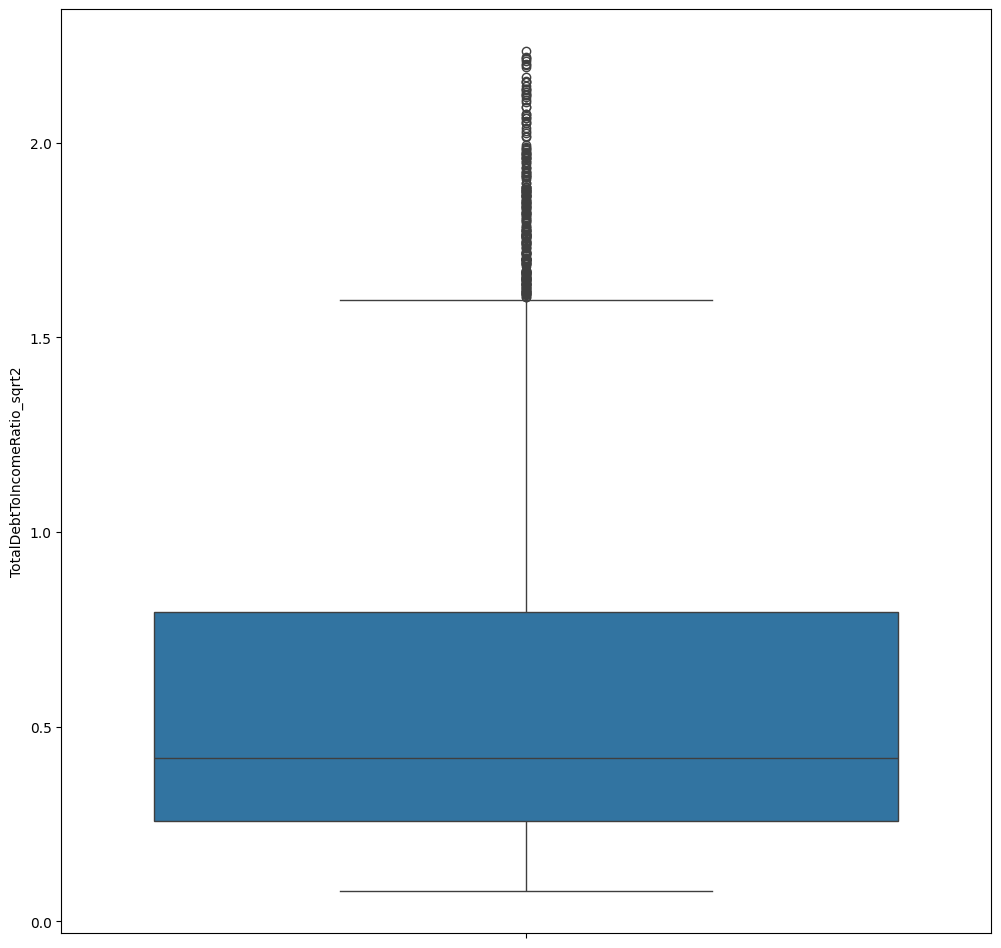

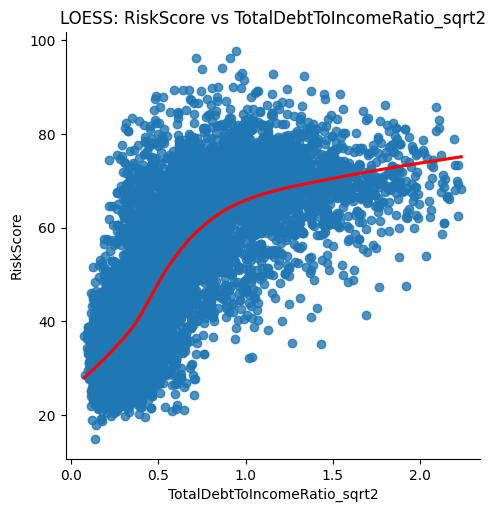

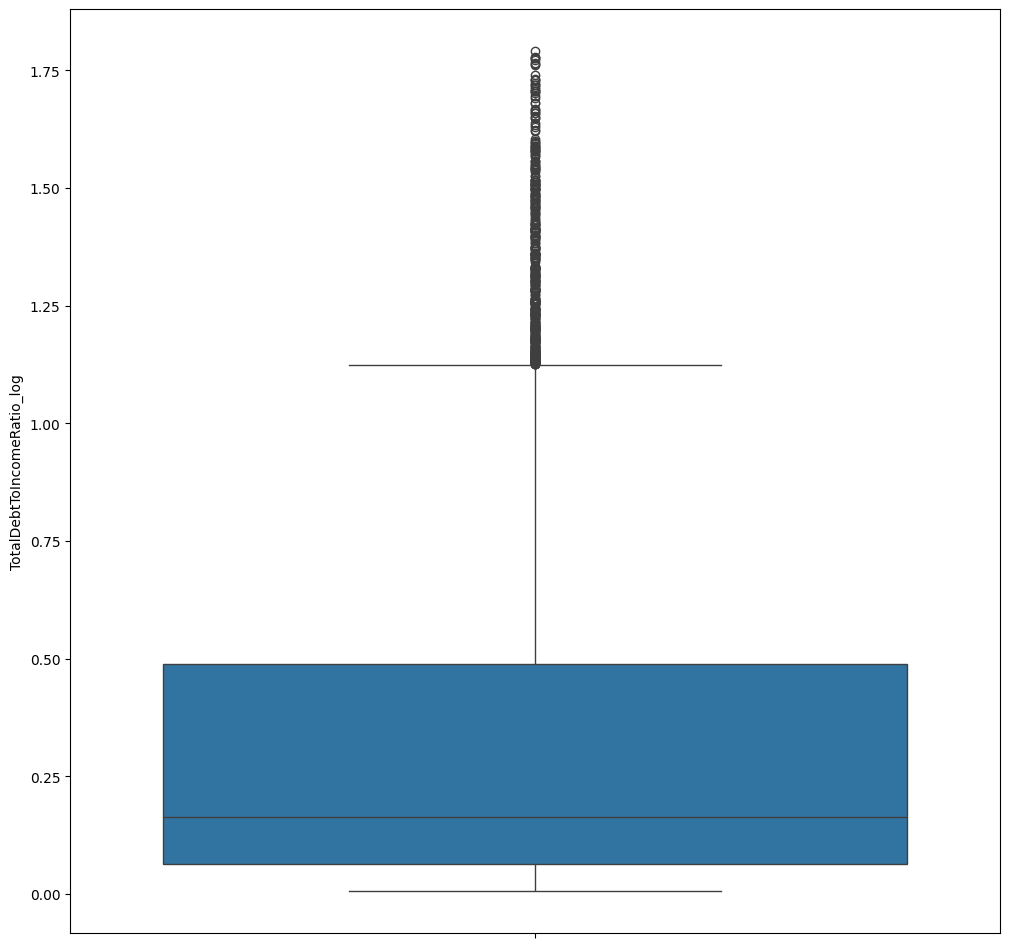

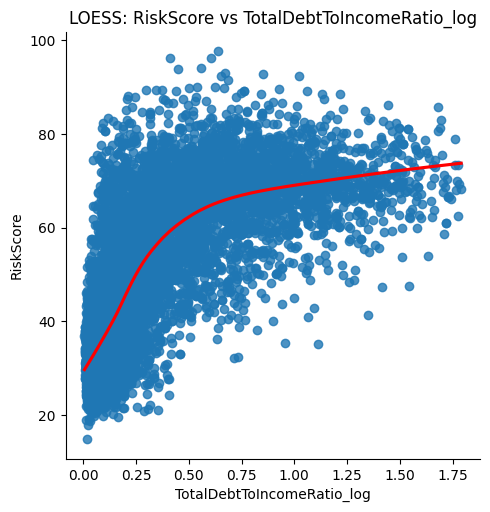

In [17]:

plt.figure(figsize=(12, 12))
sns.boxplot(df["TotalDebtToIncomeRatio_sqrt3"])

sns.lmplot(x="TotalDebtToIncomeRatio_sqrt3", y="RiskScore", data=df, lowess=True, line_kws={"color": "red"})
plt.title(f"LOESS: RiskScore vs TotalDebtToIncomeRatio_sqrt3") 

plt.figure(figsize=(12, 12))
sns.boxplot(df["TotalDebtToIncomeRatio_sqrt2"])

sns.lmplot(x="TotalDebtToIncomeRatio_sqrt2", y="RiskScore", data=df, lowess=True, line_kws={"color": "red"})
plt.title(f"LOESS: RiskScore vs TotalDebtToIncomeRatio_sqrt2")

plt.figure(figsize=(12, 12))
sns.boxplot(df["TotalDebtToIncomeRatio_log"])

sns.lmplot(x="TotalDebtToIncomeRatio_log", y="RiskScore", data=df, lowess=True, line_kws={"color": "red"})
plt.title(f"LOESS: RiskScore vs TotalDebtToIncomeRatio_log") 

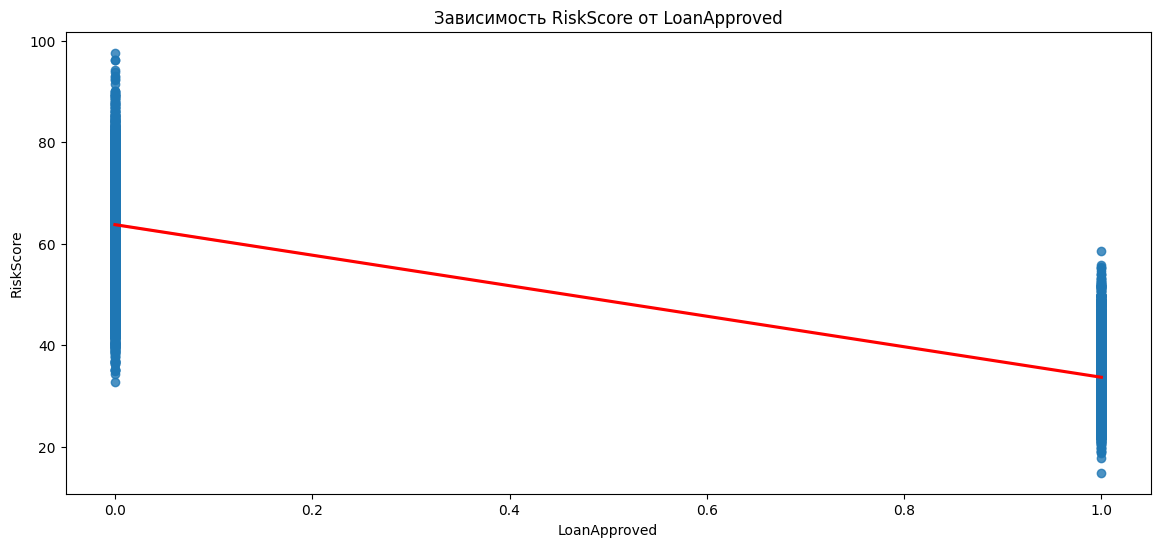

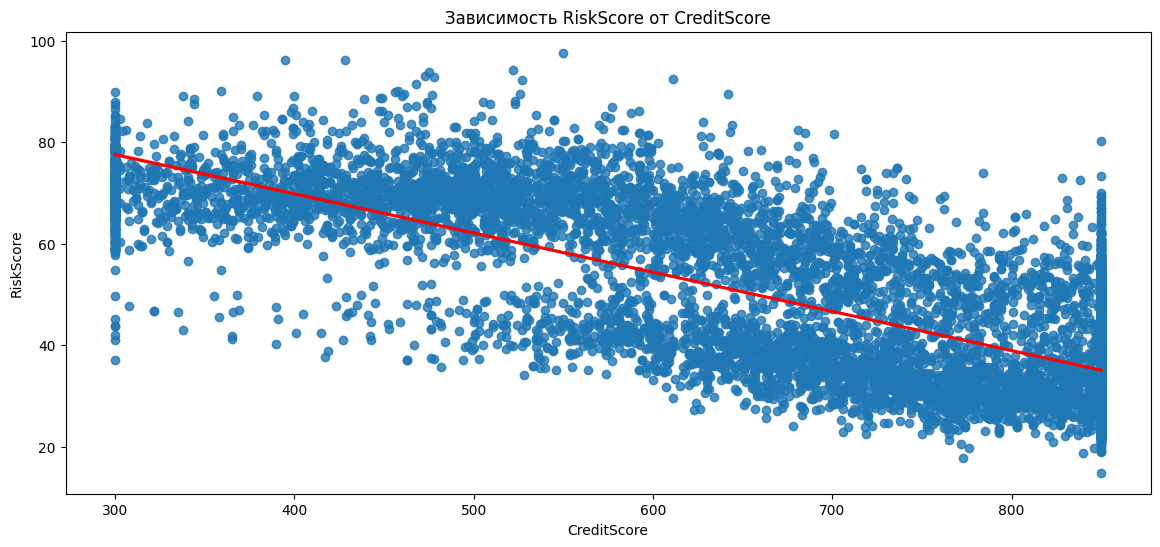

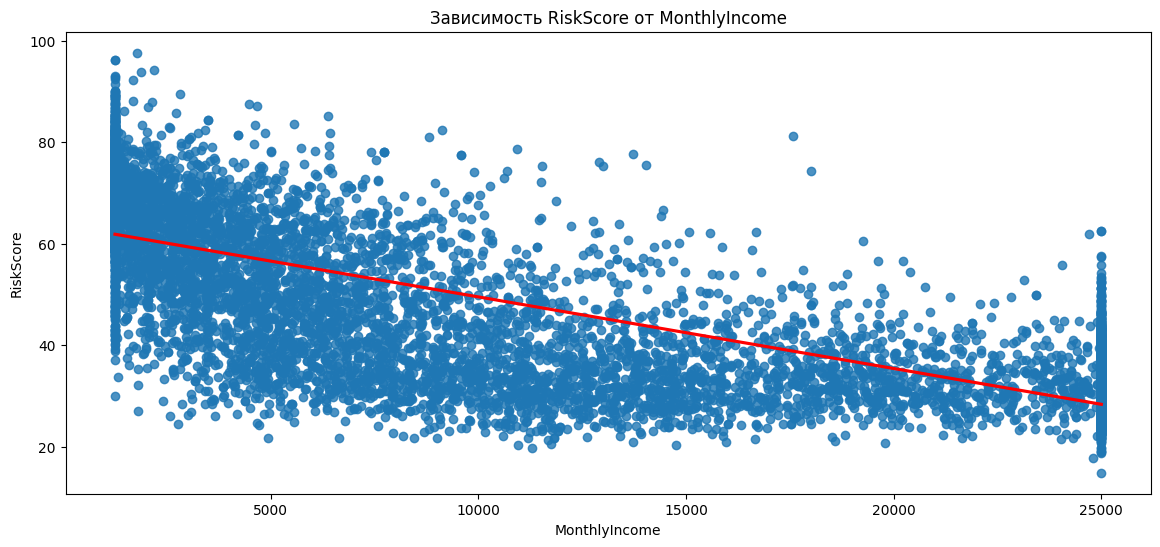

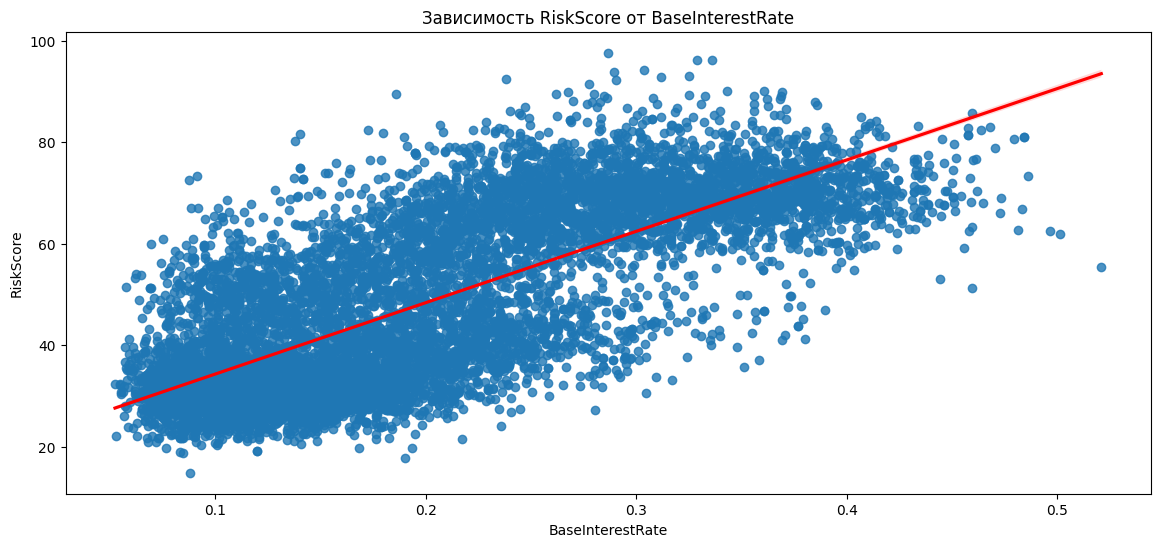

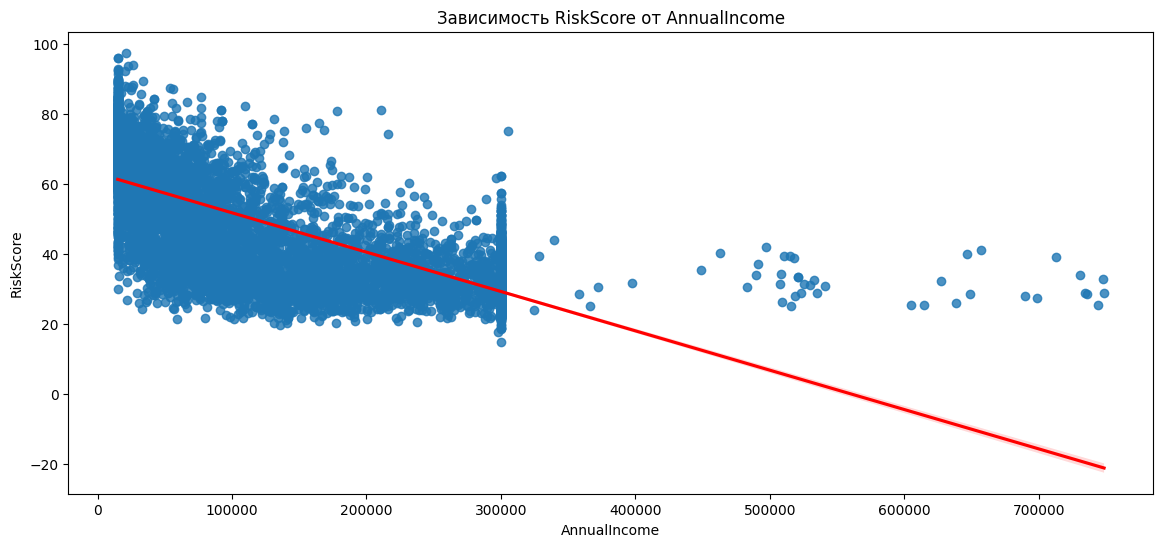

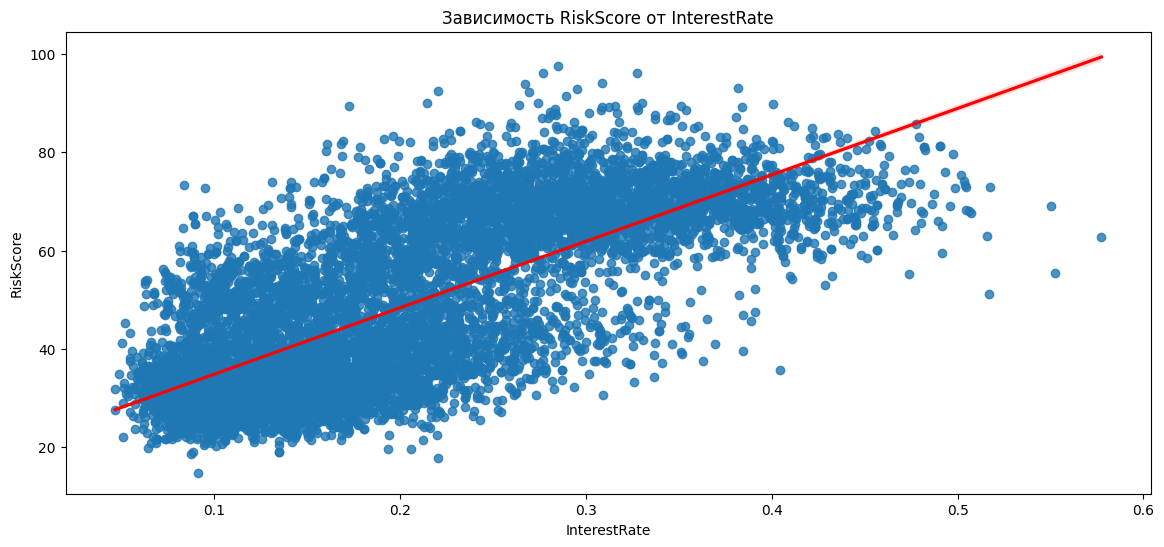

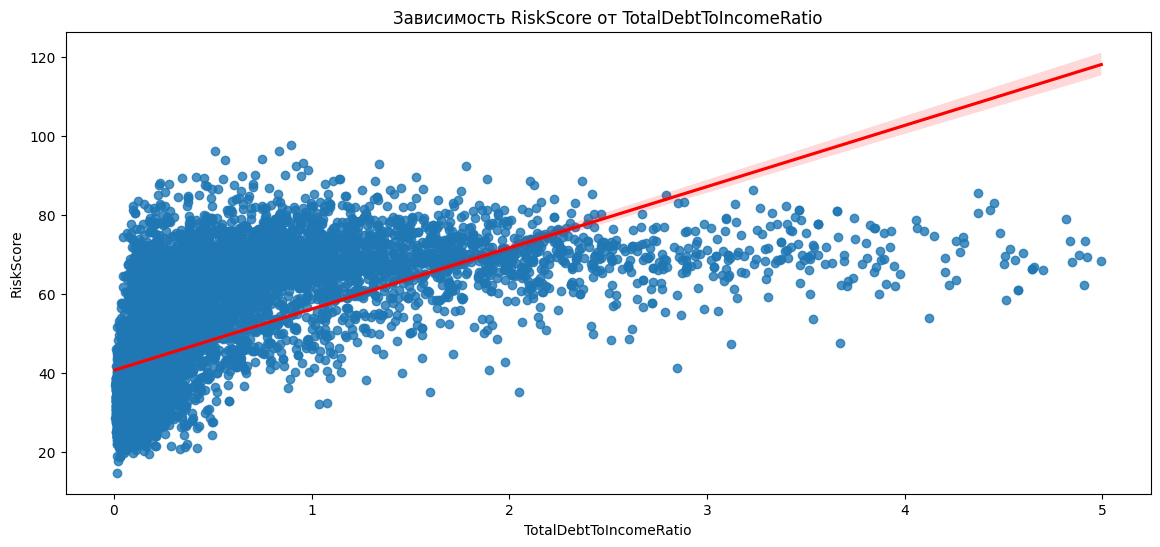

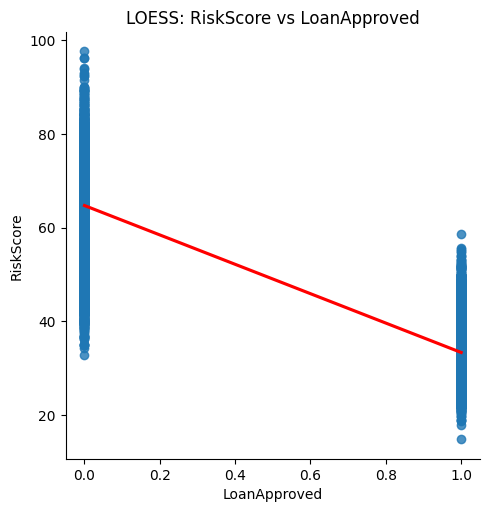

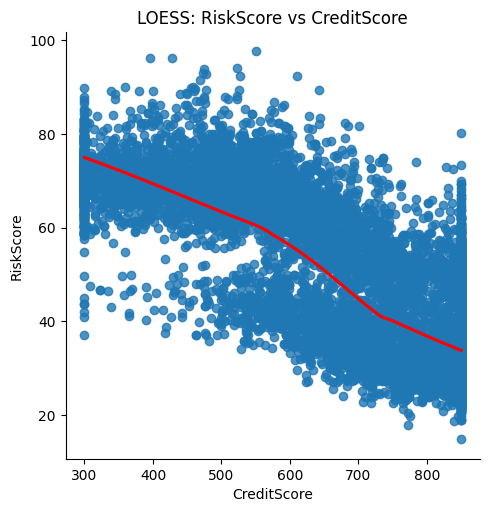

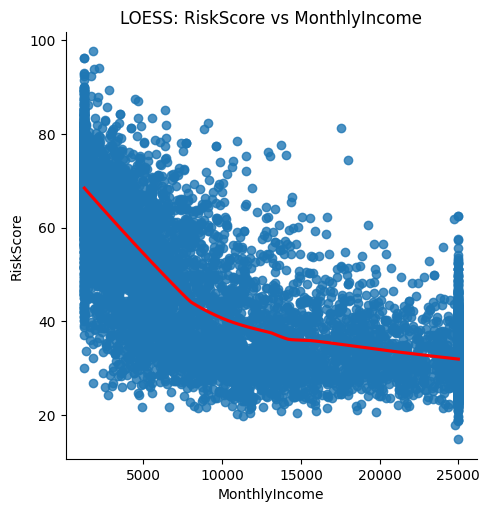

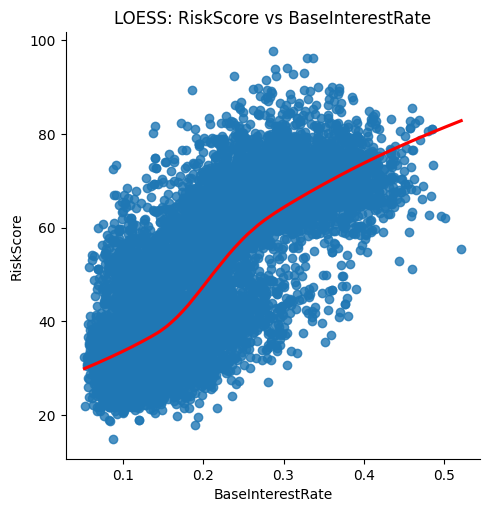

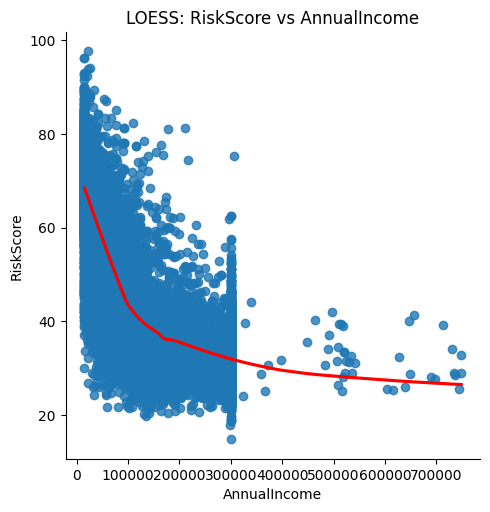

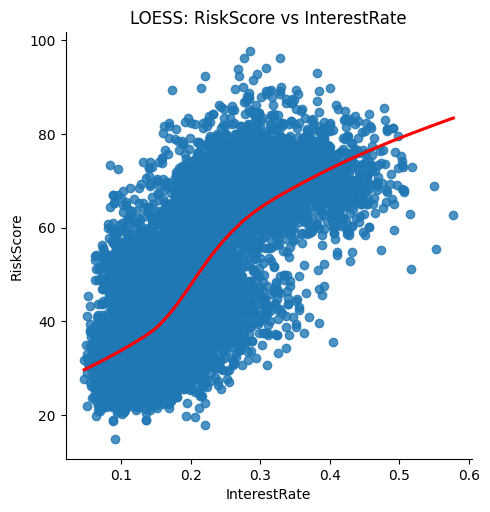

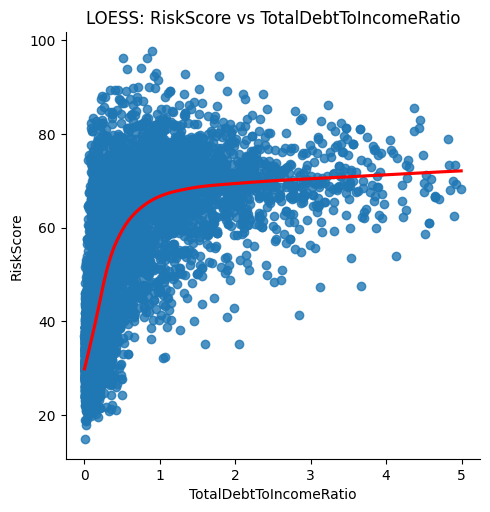

In [18]:
features = ["LoanApproved", "CreditScore", "MonthlyIncome", "BaseInterestRate", "AnnualIncome", "InterestRate", "TotalDebtToIncomeRatio"]

for feature in features :
    plt.figure(figsize=(14, 6))
    sns.regplot(x=df[feature], y=df["RiskScore"], line_kws={"color": "red"})
    plt.title(f"Зависимость RiskScore от {feature}")
    plt.show()

for feature in features :
    sns.lmplot(x=feature, y="RiskScore", data=df, lowess=True, line_kws={"color": "red"})
    plt.title(f"LOESS: RiskScore vs {feature}")


## Еще несколько финальных проверок

In [19]:
print("Количество пропусков в train данных:", df.isna().sum().sum())
print("Количество пропусков в test данных:", df_test.isna().sum().sum())

Количество пропусков в train данных: 0
Количество пропусков в test данных: 0


<Axes: >

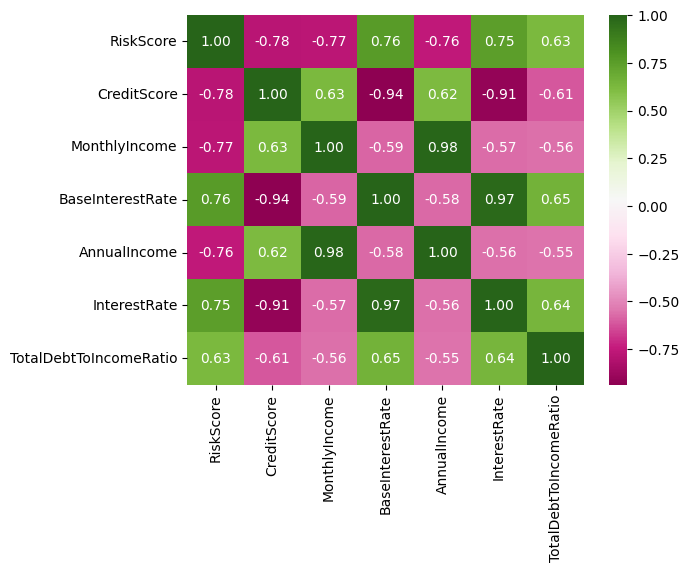

In [20]:
correlations = df[["RiskScore", "CreditScore", "MonthlyIncome", "BaseInterestRate", "AnnualIncome", "InterestRate", "TotalDebtToIncomeRatio"]].corr()

sns.heatmap(correlations, annot=True, fmt=".2f", cmap="PiYG")



# Реализуем нормализацию данных

## Z-score (стандартизация) 

### $z = \frac{x - \mu}{\sigma}$

### x - это исходное значение
### $\mu$ - это среднее значение признака
### $\sigma$ - это стандартное отклонение признака


In [75]:
# Оставляем только числовые столбцы
df_n = df.select_dtypes("number").copy()
df_test_n = df_test.select_dtypes("number").copy()

# Отделяем признаки и целевую переменную (для обучающего набора)
features = df_n.drop(columns=["RiskScore"])  
target = df_n["RiskScore"]

print(features.std().min()) 

features_z = features.apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


df_n_z = features_z.copy()
df_n_z["RiskScore"] = target

df_test_n_z = df_test_n.apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))

print(df_n_z["AnnualIncome"].mean())  # 0
print(df_n_z["AnnualIncome"].std())   # 1


0.0945600240601741
5.8080534240122625e-18
0.9999999999999998


## Min-Max нормализация

### $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$

### $x$ - это исходное значение
### $x_{min}$ и $x_{max}$ - минимальное и максимальное значения признака соответственно


In [76]:
features_mm = features.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

df_mm = features_mm.copy()
df_mm["RiskScore"] = target
df_mm_test = df_test_n.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Теперь все значения в диапазоне от 0 до 1

print(df_mm["AnnualIncome"].max()) # 1
print(df_mm["AnnualIncome"].min()) # 0



1.0
0.0


/var/folders/qy/4g4s31xn31bbxv_rjw8thkb40000gn/T/ipykernel_26944/1500489588.py:5: RuntimeWarning: overflow encountered in scalar subtract
  df_mm_test = df_test_n.apply(lambda x: (x - x.min()) / (x.max() - x.min()))


# Реализация класса линейной регрессии

# Вывод нормального уравнения

Пусть:

$ ( X \in \mathbb{R}^{m \times n}) $ — матрица признаков (с добавленным столбцом единиц) - т.к. наш b (bias) неудобен ввиде скаляра, и его удобно записать как еще один вес $w_{0}$, чтобы уравнение $\hat{y} = X'W + b$ превратить в $\hat{y} = XW$ где 
$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \dots & x_{1n} \\
1 & x_{21} & x_{22} & \dots & x_{2n} \\
1 & x_{31} & x_{32} & \dots & x_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{m1} & x_{m2} & \dots & x_{mn}
\end{bmatrix}
$$

$ ( \mathbf{y} \in \mathbb{R}^{m}) $  — вектор целевых значений

$ ( \mathbf{w} \in \mathbb{R}^{n}) $ — вектор весов

$ m $ — кол-во наблюдений


**Функция потерь (MSE)**:
$$
J(\mathbf{w}) = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2
$$

1. **Находим градиент функции потерь**:
$$
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{m} X^\top (X\mathbf{w} - \mathbf{y})
$$

2. **Приравниваем градиент к нулю (чтобы инимизировать функцию стоимости)**:
$$
X^\top (X\mathbf{w} - \mathbf{y}) = \mathbf{0}
$$

3. **Раскрываем скобки**:
$$
X^\top X\mathbf{w} = X^\top \mathbf{y}
$$

4. **Решаем**:
$$
\boxed{\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}}
$$


## Вывод градиентного спуска

## Функция потерь (MSE)
Среднеквадратичная ошибка в матричной форме:
$$
J(\mathbf{w}) = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2 = \frac{1}{2m} (X\mathbf{w} - \mathbf{y})^\top (X\mathbf{w} - \mathbf{y}),
$$


---

## Шаги вычисления градиента

### 1. Раскрываем квадрат нормы
$$
J(\mathbf{w}) = \frac{1}{2m} \left[ \mathbf{w}^\top X^\top X \mathbf{w} - 2 \mathbf{w}^\top X^\top \mathbf{y} + \mathbf{y}^\top \mathbf{y} \right].
$$

### 2. Дифференцируем по $(\mathbf{w})$
Используем правила матричного дифференцирования:

1. **Производная квадратичной формы**:
   $$
   \frac{\partial}{\partial \mathbf{w}} (\mathbf{w}^\top X^\top \mathbf{w} X ) = 2 X^\top X \mathbf{w}.
   $$

2. **Производная линейного члена**:
   $$
   \frac{\partial}{\partial \mathbf{w}} (-2 \mathbf{w}^\top X^\top \mathbf{y}) = -2 X^\top \mathbf{y}.
   $$

3. **Производная константы**:
   $$
   \frac{\partial}{\partial \mathbf{w}} (\mathbf{y}^\top \mathbf{y}) = 0.
   $$

### 3. Собираем все компоненты
$$
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{2m} \left( 2 X^\top X \mathbf{w} - 2 X^\top \mathbf{y} \right).
$$

---

## Итоговая формула градиента
$$
\boxed{
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{m} X^\top (X\mathbf{w} - \mathbf{y})
}
$$

---

## Пояснение
- **Градиент** показывает направление наискорейшего роста функции потерь.
- **Отрицательный градиент** $(-\nabla J)$ указывает направление минимизации ошибки.
- Формула используется в градиентном спуске для обновления весов:
  $$
  \mathbf{w}_{j} = \mathbf{w}_{j-1} - \alpha \cdot \nabla_{\mathbf{w}} J(\mathbf{w}),
  $$
  где $\alpha$ — скорость обучения.


In [24]:
import numpy as np

class LinearRegression:
    def __init__(self, method="analytical", learning_rate=0.01, iter=1e4) :
        self.method = method
        self.learning_rate = learning_rate # нужна для корректировки узнать какой
        self.iter = int(iter)
        self.weights = None

    def add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]
    
    def fit(self, X, y):
        # Добавляем единичный столбец
        X = self.add_bias(X)
        m = X.shape[0] # кол-во объектов
        n = X.shape[1] # кол-во признаков

        
        if self.method == "analytical":
            self.weights = np.linalg.pinv(X.T @ X) @ X.T @ y
        elif self.method == "gradient": #  обновляем веса после обработки всей выборки
            
            # Для начала инициализируем вектор весов нулями. ГС быстро исправит ошибки
            self.weights = np.zeros(n)

            for i in range(self.iter):
                gradient = (1 / m) * (X.T @ (X @ self.weights - y)) # X @ self.weights - это наше предсказание, а y - это реальное значение
                self.weights -= self.learning_rate * gradient # обновляем веса, так, чтобы функция потерь уменьшилась, тк градиент показывает в каком направлении изменять веса, чтобы ошибка снижалась
       
        elif self.method == "sgradient":
            # Обновляем веса для каждого примера, что может ускорить обучение для больших наборов данных
            self.weights = np.zeros(n)
            for epoch in range(self.iter):
                # Перемешиваем индексы объектов для случайного порядка
                indices = np.arange(m)
                np.random.shuffle(indices)
                for i in indices:
                    xi = X[i:i+1]  # выбираем один объект в виде строки
                    yi = y[i]      # целевое значение для объекта
                    # Вычисляем градиент для одного примера:
                    gradient = xi.T * (xi @ self.weights - yi)
                    # Обновляем веса для этого примера
                    self.weights -= self.learning_rate * gradient.flatten() #  (flatten, чтобы получить одномерный массив)
        else:
            raise ValueError("Метод должен быть 'analytical', 'gradient' или 'sgradient'")


    def predict(self, X):
        X = self.add_bias(X)
        return X @ self.weights
            
            
            
    

In [25]:
from sklearn.metrics import mean_squared_error

def mse(y_real, y_pred):
    return ((y_real - y_pred) ** 2).mean()

X = df_n_z.drop("RiskScore", axis=1).values
X_test = df_test_n_z.drop(columns=["ID"]).values
y = df_n_z["RiskScore"].values 

model1 = LinearRegression(method="analytical")
model1.fit(X, y)
predictions1 = model1.predict(X)
mse1 = mse(predictions1, y)
smse1 = mean_squared_error(predictions1, y)

model2 = LinearRegression(method="gradient", learning_rate=0.01, iter=1e4)
model2.fit(X, y)
predictions2 = model2.predict(X)
mse2 = mse(predictions2, y)
smse2 = mean_squared_error(predictions2, y)

model3 = LinearRegression(method="sgradient", learning_rate=0.001, iter=300)
model3.fit(X, y)
predictions3 = model3.predict(X)
mse3 = mse(predictions3, y)
smse3 = mean_squared_error(predictions3, y)


print("My MSE (Analytical):", mse1)
print("My MSE (Gradient):", mse2)
print("My MSE (Stochastic):", mse3)

print("sklearn MSE (Analytical):", smse1)
print("sklearn MSE (Gradient):", smse2)
print("sklearn MSE (Stochastic):", smse3)
 
submission_df = pd.DataFrame({
    "ID": test_ids,
    "RiskScore": model3.predict(X_test)
})

submission_df.to_csv("kaggle_submission.csv", index=False)

My MSE (Analytical): 10.348867587180072
My MSE (Gradient): 11.482189025134335
My MSE (Stochastic): 11.332863830216226
sklearn MSE (Analytical): 10.348867587180072
sklearn MSE (Gradient): 11.482189025134335
sklearn MSE (Stochastic): 11.332863830216226


### - Аналитический метод дал наилучший результат (MSE ≈ 10.35), так как точно решает уравнение при условии хороших данных
### - Градиентный и стохастический методы дали близкие результаты (≈11.4–11.5), но немного хуже из-за приближённого характера

## Также заметим, что разницы между моей реализацией MSE и sklearn нету - значения одинаковые (а что тут еще придумаешь :) )

## Сравнение MAE от меня и от sklearn

In [26]:
from sklearn.metrics import mean_absolute_error

def mae (y_real, y_pred) :
    return np.mean(np.abs(y_real - y_pred))
    
mae1 = mae(predictions1, y)
smae1 = mean_absolute_error(predictions1, y)

mae2 = mae(predictions2, y)
smae2 = mean_absolute_error(predictions2, y)

mae3 = mae(predictions3, y)
smae3 = mean_absolute_error(predictions3, y)


print("My MAE (Analytical):", mae1)
print("My MAE (Gradient):", mae2)
print("My MAE (Stochastic):", mae3)

print("sklearn MAE (Analytical):", smae1)
print("sklearn MAE (Gradient):", smae2)
print("sklearn MAE (Stochastic):", smae3)

My MAE (Analytical): 2.5251030404168273
My MAE (Gradient): 2.6652211642684307
My MAE (Stochastic): 2.6451548168665533
sklearn MAE (Analytical): 2.5251030404168273
sklearn MAE (Gradient): 2.6652211642684307
sklearn MAE (Stochastic): 2.6451548168665533


## Также разницы нету

## Осталось MAPE (Mean Absolute Percentage Error)

In [127]:
from sklearn.metrics import mean_absolute_percentage_error

def mape(y_real, y_pred) :
    return np.mean(np.abs((y_real - y_pred) / y_real)) * 100

mape1 = mape(predictions1, y)
smape1 = mean_absolute_percentage_error(predictions1, y)

mape2 = mape(predictions2, y)
smape2 = mean_absolute_percentage_error(predictions2, y)

mape3 = mape(predictions3, y)
smape3 = mean_absolute_percentage_error(predictions3, y)


print("My MAPE (Analytical):", mape1)
print("My MAPE (Gradient):", mape2)
print("My MAPE (Stochastic):", mape3)

print("sklearn MAPE (Analytical):", smape1 * 100)
print("sklearn MAPE (Gradient):", smape2 * 100)
print("sklearn MAPE (Stochastic):", smape3 * 100)


    

My MAPE (Analytical): 5.837588835658947
My MAPE (Gradient): 6.1480555010698295
My MAPE (Stochastic): 6.100158227617794
sklearn MAPE (Analytical): 5.837588835658947
sklearn MAPE (Gradient): 6.1480555010698295
sklearn MAPE (Stochastic): 6.100158227617794


In [18]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X, y)  

submission_df = pd.DataFrame({
    "ID": test_ids,
    "RiskScore": sklearn_model.predict(X_test) 
})

submission_df.to_csv("kaggle_submission.csv", index=False)

## Реалиуем кросс-валидацию k-fold

### Кросс-валидация — это способ оценить качество модели на нескольких разбиениях, а не на одном полном DF. Более честная MSE или другая метрика

### K-fold: Каждый фолд представляет собой независимый обучающий и тестовый набор данных, поэтому мы создаем для каждого отдельную модель

In [104]:
def k_fold(model_c, X, y, k=5, **model_params):
    fold_size = len(X) // k
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    mse_scores = []

    for i in range(k):
        start_indx = i * fold_size
        end_indx = (i + 1) * fold_size if i != k - 1 else len(X)

        test_idx = indices[start_indx:end_indx]
        train_idx = np.concatenate([indices[:start_indx], indices[end_indx:]])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Создаём новую модель на каждой итерации
        model = model_c(**model_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = np.mean((y_pred - y_test) ** 2)
        mse_scores.append(mse)

    return np.mean(mse_scores)


In [105]:
mse_kfold = k_fold(LinearRegression, X, y, k=5, method="gradient", learning_rate=0.01, iter=10000)
print(f"K-Fold MSE (k=5): {mse_kfold:.4f}")


K-Fold MSE (k=5): 11.6432


## Leave-One-Out Cross-Validation (LOO или LOO-CV)

### Суть такая: берем объект - это наш тест, а остальное это наши train. Работает медленее, но более точно, чем  k-fold, т.к каждый раз размер нашего фолда равен размеру выборки

In [116]:
def loo(model_c, X, y, **model_params):
    n = len(X)
    mse_scores = []

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        X_test = X[i:i+1]
        y_real = y[i]

        model = model_c(**model_params)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)[0]

        mse_scores.append((y_pred - y_real) ** 2)

    return np.mean(mse_scores)


In [117]:
mse_loo = loo(LinearRegression, X, y, method="gradient", learning_rate=0.01, iter=10)
print(f"LOO MSE : {mse_loo:.4f}")


LOO MSE : 1971.7209


## Попробуем реализовать регуляризацию 

#### Регуляризация нам нужна, чтобы предотвратить переобучение (overfitting). Он добавляет штраф к функции потерь, чтобы наказать модель за слишком большие веса. Без регуляризации модель может очень хорошо подогнать свои веса под обучающую выборку, но при этом сильно подгоняться под случайный шум. И когда применяется модель к новым данным, она будет давать плохие предсказания (переобучение). Без регуляризации модель может выбрать очень большие веса, чтобы минимизировать ошибку на обучающих данных. А регуляризация заставляет модель выбирать более маленькие веса, делая её более обобщающей.

Улучшим мою предыдущую версию линейной регрессии, добавив регуляризацию

### L2-регуляризация (Ridge)

$$ L(w) = MSE +\lambda\sum_{j=1}^{n} w_{j}^2 $$

В функцию потерь добавляется штраф, равный сумме квадратов весов и умноженный на коэф, который определяет силу штрафа.

(https://proproprogs.ru/ml/ml-l2-regulyarizator-matematicheskoe-obosnovanie-i-primer-raboty)

## Исходная функция потерь
Функция потерь с L2-регуляризацией:
$$
L(w) = \underbrace{\frac{1}{2n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}_{\text{MSE}} + \underbrace{\frac{\lambda}{2}\sum_{j=1}^{n} w_{j}^2}_{\text{L2-штраф}}
$$
где:
- $\hat{y}_i = X_i w$ — предсказание модели,
- $\lambda$ — коэффициент регуляризации,
- $w$ — вектор весов.

---

## Шаг 1. Матричная запись
Перепишем в матричной форме:
$$
L(w) = \frac{1}{2n} \|y - Xw\|^2 + \frac{\lambda}{2} w^T w
$$

---

## Шаг 2. Вычисление градиента
Возьмем производную по $w$:
$$
\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n} X^T(Xw - y) + \lambda w
$$

**Пояснение:**
1. Производная MSE:  
   $$
   \frac{\partial}{\partial w} \left( \frac{1}{2n} \|y - Xw\|^2 \right) = \frac{1}{n} X^T(Xw - y)
   $$
2. Производная L2-штрафа:  
   $$
   \frac{\partial}{\partial w} \left( \frac{\lambda}{2} w^T w \right) = \lambda w
   $$

---

## Шаг 3. Приравнивание градиента к нулю
Для нахождения минимума:
$$
\frac{1}{n} X^T(Xw - y) + \lambda w = 0
$$

Умножим обе части на $n$:
$$
X^T Xw - X^T y + n \lambda w = 0
$$

---

## Шаг 4. Вынос $w$ за скобки
Перепишем в матричной форме:
$$
(X^T X + \lambda' I) w = X^T y
$$
где:
- $\lambda' = n \lambda$
- $I$ — единичная матрица размерности $(m \times m)$

---

## Шаг 5. Выносим w
$$
w = (X^T X + \lambda I)^{-1} X^T y
$$


## L1-регуляризация (Lasso) - имеет свойство делать веса разрежёнными – многие веса становятся равными нулю

#### Оставляем только важные признаки, остальные зануляем.


$$ L(w) = MSE +\lambda\sum_{j=1}^{n} |w_{j}| $$

Функция штрафа с модулем не является гладкой (недифференцируемой в точке 0), что усложняет аналитическое решение. Для нормального уравнения L1-регуляризация не имеет закрытой формы, поэтому её обычно применяют итеративно (например, через градиентный спуск).

Функция потерь с L1-регуляризацией:
$$
L(w) = \underbrace{\frac{1}{2n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}_{\text{MSE}} + \underbrace{\lambda \sum_{j=1}^m |w_j|}_{\text{L1-штраф}}
$$
где:
- $\hat{y}_i = X_i w$ — предсказание модели,
- $\lambda$ — коэффициент регуляризации,
- $w_j$ — веса модели

---

## Шаг 1. Матричная запись
Перепишем в матричной форме:
$$
L(w) = \frac{1}{2n} \|y - Xw\|^2 + \lambda \|w\|_1
$$

$ \|w\|_1 $ - Манхэттенское расстояние. Для вектора представляет собой сумму модулей всех его элементов.
 
---

## Шаг 2. Градиент
Функция $|w_j|$ **не дифференцируема** в точке $w_j = 0$. Используем:
$$
 \text{sign}(w_j) = \frac{\partial |w_j|}{\partial w_j} = 
\begin{cases} 
1, & w_j > 0 \\
-1, & w_j < 0 \\
0, & w_j = 0 
\end{cases}
$$

Общий градиент функции потерь:
$$
\frac{\partial L}{\partial w_j} = \frac{1}{n} \sum_{i=1}^n (X_{ij}(\hat{y}_i - y_i)) + \lambda \cdot \text{sign}(w_j)
$$

---


## L1 + L2 - регуляризация (Elastic Net)

### Объединяет L1 и L2 штрафы


$$ L(w) = MSE + \lambda_{1}\sum_{j=1}^{n} w_{j}^2 +\lambda_{2}\sum_{j=1}^{n} |w_{j}| $$

Elastic Net объединяет преимущества L1 и L2, компенсируя недостатки каждого метода. Пример:

**Коррелированные признаки**
- **Проблема**: В задачах с высокой корреляцией признаков:
  - **Lasso (L1)** случайно выбирает один признак из группы коррелированных, игнорируя остальные.
  - **Ridge (L2)** сохраняет все признаки, но не выполняет отбор.
- **Решение Elastic Net**: 
  - **L2-компонента** "группирует" коррелированные признаки, сохраняя их все, но с уменьшенными весами.
  - **L1-компонента** обнуляет неважные признаки внутри группы.

## $ L_{p} $ - регуляризация

#### Это обощение L1 и L2 регуляризации. Вместо фиксированной степени 1 (L1) или 2 (L2) мы используем любое значение p > 0.

$$ L(w) = MSE  +\lambda\sum_{j=1}^{n} |w_{j}|^p $$

## Особенности для разных \( p \)
### 1. **\( p = 1 \) (L1)**:
- Градиент регуляризации: $ \lambda \cdot \text{sign}(w_j) $
- **Эффект**: Обнуление некоторых весов (разреженность).

### 2. **\( p = 2 \) (L2)**:
- Градиент регуляризации: $ \lambda \cdot w_j$
- **Эффект**: Равномерное сокращение весов.

### 3. **\( 0 < p < 1 \)**:
- Функция **не выпукла**, оптимизация сложна.
- Градиент: $ \lambda \cdot p \cdot |w_j|^{p-1} \cdot \text{sign}(w_j) $
- **Эффект**: Сильнее обнуляет веса, чем L1, для малых весов. Чем меньше p, тем сильнее зануляются веса.

### 4. **\( p > 2 \)**:
- Штрафует большие веса сильнее, чем L2.
- Нрадиент например для: $ p = 3 \rightarrow \lambda \cdot 3 w_j^2 \cdot \text{sign}(w_j) $

In [59]:
import numpy as np

class LinearRegressionL:
    def __init__(self, method="analytical", learning_rate=0.01, iter=1e4, regularization=None, lambda_=0.0, p=2) :
        self.method = method
        self.learning_rate = learning_rate # нужна для корректировки узнать какой
        self.iter = int(iter)
        self.weights = None
        self.regularization = regularization
        self.lambda_ = lambda_
        self.p = p

    def add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]
    
    def fit(self, X, y):
        # Добавляем единичный столбец
        X = self.add_bias(X)
        m = X.shape[0] # кол-во объектов
        n = X.shape[1] # кол-во признаков

        
        if self.method == "analytical":
            if self.regularization is None:
                self.weights = np.linalg.inv(X.T @ X) @ X.T @ y
                
            elif self.regularization == "L2":
                I = np.eye(n)
                I[0, 0] = 0  # первый вес не штрафуется (тк он не связан с признаками и отвечает только за смещение)
                self.weights = np.linalg.pinv(X.T @ X + self.lambda_ * I) @ X.T @ y
            else:
                raise ValueError("Аналитический метод поддерживает только отсутствие регуляризации или L2.")

            
        elif self.method == "gradient": #  обновляем веса после обработки всей выборки
            
            # Для начала инициализируем вектор весов нулями. ГС быстро исправит ошибки
            self.weights = np.zeros(n)

            for i in range(self.iter):
                gradient = (1 / m) * (X.T @ (X @ self.weights - y)) # X @ self.weights - это наше предсказание, а y - это реальное значение
                
                if self.regularization == "L2":
                    l_grad = self.lambda_ * self.weights
                    l_grad[0] = 0 # bias не штрафуем
                    gradient += l_grad
                elif self.regularization == "L1":
                    l_grad = self.lambda_ * np.sign(self.weights)
                    l_grad[0] = 0 # bias не штрафуем
                    gradient += l_grad
                elif self.regularization == "ElasticNet":
                    lambda1 = self.lambda_[0]
                    lambda2 = self.lambda_[1]
                    l_grad = lambda1 * np.sign(self.weights) + lambda2 * self.weights
                    l_grad[0] = 0 # bias не штрафуем
                    gradient += l_grad
                elif self.regularization == "Lp":
                    l_grad = self.lambda_ * self.p * (np.abs(self.weights) ** (self.p - 1)) * np.sign(self.weights)
                    l_grad[0] = 0
                    gradient += l_grad
                self.weights -= self.learning_rate * gradient # обновляем веса, так, чтобы функция потерь уменьшилась, тк градиент показывает в каком направлении изменять веса, чтобы ошибка снижалась
       
        elif self.method == "sgradient":
            # Обновляем веса для каждого примера, что может ускорить обучение для больших наборов данных
            self.weights = np.zeros(n)
            for epoch in range(self.iter):
                # Перемешиваем индексы объектов для случайного порядка
                indices = np.arange(m)
                np.random.shuffle(indices)
                for i in indices:
                    xi = X[i:i+1]  # выбираем один объект в виде строки
                    yi = y[i]      # целевое значение для объекта
                    # Вычисляем градиент для одного примера:
                    gradient = xi.T * (xi @ self.weights - yi)
                    gradient = gradient.flatten() 
                    if self.regularization == "L2":
                        l_grad = self.lambda_ * self.weights
                        l_grad[0] = 0 # bias не штрафуем
                        gradient += l_grad
                    elif self.regularization == "L1":
                        l_grad = self.lambda_ * np.sign(self.weights)
                        l_grad[0] = 0 # bias не штрафуем
                        gradient += l_grad
                    elif self.regularization == "ElasticNet":
                        lambda1 = self.lambda_[0]
                        lambda2 = self.lambda_[1]
                        l_grad = lambda1 * np.sign(self.weights) + lambda2 * self.weights
                        l_grad[0] = 0 # bias не штрафуем
                        gradient += l_grad
                    elif self.regularization == "Lp":
                        l_grad = self.lambda_ * self.p * (np.abs(self.weights) ** (self.p - 1)) * np.sign(self.weights)
                        l_grad[0] = 0
                        gradient += l_grad
                        # Обновляем веса для этого примера
                    self.weights -= self.learning_rate * gradient
        else:
            raise ValueError("Метод должен быть 'analytical', 'gradient' или 'sgradient'")


    def predict(self, X):
        X = self.add_bias(X)
        return X @ self.weights
            
            
            
    

In [62]:
from sklearn.metrics import mean_squared_error

model_custom = LinearRegressionL(method="gradient", learning_rate=0.01, iter=10000, regularization="L2", lambda_=0.01)
model_custom.fit(X, y)
pred_custom = model_custom.predict(X)

print("Custom model MSE:", mean_squared_error(y, pred_custom))

submission_df = pd.DataFrame({
    "ID": test_ids,
    "RiskScore": model_custom.predict(X_test)
})

submission_df.to_csv("kaggle_submission.csv", index=False)

Custom model MSE: 11.732592430168804
